# Regression Analysis

This notebook examines the relationship between healthcare accessibility, health outcomes, socioeconomic factors, and life expectancy in Germany and India between 1990 and 2024.

The analysis begins with a simple baseline model using Year as the only predictor. More complex healthcare models will be developed progressively.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv(r"C:/Users/Admin/OneDrive/Documents/Thesis/master_dataset_updated(in).csv")

df.head()

,Year,Country,Infant_Mortality,GDP_per_Capita,Urban_Population,Total_Population,Obesity_Prevalence,Cardiovascular_Deaths_Rate,Chronic_Respiratory_Deaths_Rate,Diabetes_Deaths_Rate,...,UHC_Coverage_Index,NCD_Mortality_Probability,Diabetes_Prevalence,Hospital_Density,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Birth_Rate,Health_Expenditure_y,Out_of_Pocket
0,1990,Germany,7.0,19467.81503,63557004,79433029,15.49,544.715720,48.364862,26.707671,...,84.0,13.25,5.18,2.235365,75.085634,2.745,10.4,11.4,8.404808,14.119194
1,1991,Germany,6.6,21000.69555,64026873,80013896,15.91,528.670040,47.457809,27.173112,...,84.0,13.25,5.37,2.235365,75.319512,2.745,10.1,10.4,8.516111,14.041934
2,1992,Germany,6.2,21745.81780,64520686,80624598,16.35,505.608833,45.389481,27.534647,...,84.0,13.25,5.55,2.235365,75.819512,2.816,9.9,10.0,8.627414,13.964675
3,1993,Germany,5.8,21900.19791,64951514,81156363,16.80,506.565680,45.945774,30.114751,...,84.0,13.25,5.72,2.235365,75.870732,2.904,9.7,9.8,8.738717,13.887415
4,1994,Germany,5.5,22869.21244,65182721,81438348,17.30,493.041589,44.860060,29.862112,...,84.0,13.25,5.88,2.235365,76.270732,2.977,9.7,9.5,8.850019,13.810155


In [4]:
df.shape

(70, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             70 non-null     int64  
 1   Country                          70 non-null     object 
 2   Infant_Mortality                 70 non-null     float64
 3   GDP_per_Capita                   70 non-null     float64
 4   Urban_Population                 70 non-null     int64  
 5   Total_Population                 70 non-null     int64  
 6   Obesity_Prevalence               70 non-null     float64
 7   Cardiovascular_Deaths_Rate       70 non-null     float64
 8   Chronic_Respiratory_Deaths_Rate  70 non-null     float64
 9   Diabetes_Deaths_Rate             70 non-null     float64
 10  Neoplasms_Deaths_Rate            70 non-null     float64
 11  UHC_Coverage_Index               70 non-null     float64
 12  NCD_Mortality_Probabilit

In [6]:
df.isnull().sum()

Year                               0
Country                            0
Infant_Mortality                   0
GDP_per_Capita                     0
Urban_Population                   0
Total_Population                   0
Obesity_Prevalence                 0
Cardiovascular_Deaths_Rate         0
Chronic_Respiratory_Deaths_Rate    0
Diabetes_Deaths_Rate               0
Neoplasms_Deaths_Rate              0
UHC_Coverage_Index                 0
NCD_Mortality_Probability          0
Diabetes_Prevalence                0
Hospital_Density                   0
Life_Expectancy                    0
Physician_Density                  0
Hospital_Beds_Per_1000             0
Birth_Rate                         0
Health_Expenditure_y               0
Out_of_Pocket                      0
dtype: int64

In [7]:
print(df["Country"].unique())
print(df["Year"].min())
print(df["Year"].max())

['Germany' 'India']
1990
2024


In [8]:
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

df.head()

,Year,Country,Infant_Mortality,GDP_per_Capita,Urban_Population,Total_Population,Obesity_Prevalence,Cardiovascular_Deaths_Rate,Chronic_Respiratory_Deaths_Rate,Diabetes_Deaths_Rate,...,UHC_Coverage_Index,NCD_Mortality_Probability,Diabetes_Prevalence,Hospital_Density,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Birth_Rate,Health_Expenditure_y,Out_of_Pocket
0,1990,Germany,7.0,19467.81503,63557004,79433029,15.49,544.715720,48.364862,26.707671,...,84.0,13.25,5.18,2.235365,75.085634,2.745,10.4,11.4,8.404808,14.119194
1,1991,Germany,6.6,21000.69555,64026873,80013896,15.91,528.670040,47.457809,27.173112,...,84.0,13.25,5.37,2.235365,75.319512,2.745,10.1,10.4,8.516111,14.041934
2,1992,Germany,6.2,21745.81780,64520686,80624598,16.35,505.608833,45.389481,27.534647,...,84.0,13.25,5.55,2.235365,75.819512,2.816,9.9,10.0,8.627414,13.964675
3,1993,Germany,5.8,21900.19791,64951514,81156363,16.80,506.565680,45.945774,30.114751,...,84.0,13.25,5.72,2.235365,75.870732,2.904,9.7,9.8,8.738717,13.887415
4,1994,Germany,5.5,22869.21244,65182721,81438348,17.30,493.041589,44.860060,29.862112,...,84.0,13.25,5.88,2.235365,76.270732,2.977,9.7,9.5,8.850019,13.810155


In [9]:
df["Life_Expectancy"].describe()

count    70.000000
mean     72.279807
std       7.467225
min      58.618000
25%      65.914000
50%      73.660317
75%      79.433537
max      81.292683
Name: Life_Expectancy, dtype: float64

In [10]:
df["Life_Expectancy"].isnull().sum()

0

In [11]:
model0_data = df[["Year", "Life_Expectancy"]].dropna()

model0_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [12]:
model0_data.shape

(70, 2)

In [13]:
X = model0_data[["Year"]]
y = model0_data["Life_Expectancy"]

In [14]:
model0 = LinearRegression()

model0.fit(X, y)

LinearRegression()

In [15]:
germany_data = df[df["Country"] == "Germany"][["Year", "Life_Expectancy"]].dropna()

germany_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [16]:
germany_data = df[df["Country"] == "Germany"][["Year", "Life_Expectancy"]].dropna()

germany_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [17]:
X_germany = germany_data[["Year"]]
y_germany = germany_data["Life_Expectancy"]

In [18]:
model_germany = LinearRegression()

model_germany.fit(X_germany, y_germany)

LinearRegression()

In [19]:
print("Germany coefficient:", model_germany.coef_[0])
print("Germany intercept:", model_germany.intercept_)

Germany coefficient: 0.18249820992156862
Germany intercept: -287.3001505177311


In [20]:
y_pred_germany = model_germany.predict(X_germany)

y_pred_germany[:5]

array([75.87128723, 76.05378544, 76.23628365, 76.41878186, 76.60128007])

In [21]:
r2_germany = r2_score(y_germany, y_pred_germany)

print("Germany R²:", r2_germany)

Germany R²: 0.9220516821098859


In [22]:
rmse_germany = np.sqrt(
    mean_squared_error(y_germany, y_pred_germany)
)

print("Germany RMSE:", rmse_germany)

Germany RMSE: 0.5359008382890955


In [23]:
germany_baseline = pd.DataFrame({
    "Country": ["Germany"],
    "Model": ["Baseline: Life Expectancy ~ Year"],
    "Coefficient_Year": [model_germany.coef_[0]],
    "Intercept": [model_germany.intercept_],
    "R2": [r2_germany],
    "RMSE": [rmse_germany]
})

germany_baseline

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901


In [24]:
india_data = df[df["Country"] == "India"][["Year", "Life_Expectancy"]].dropna()

india_data.head()

,Year,Life_Expectancy
35,1990,58.618
36,1991,59.032
37,1992,59.445
38,1993,59.823
39,1994,60.237


In [25]:
india_data.shape

(35, 2)

In [26]:
X_india = india_data[["Year"]]
y_india = india_data["Life_Expectancy"]

In [27]:
model_india = LinearRegression()

model_india.fit(X_india, y_india)

LinearRegression()

In [28]:
print("India coefficient:", model_india.coef_[0])
print("India intercept:", model_india.intercept_)

India coefficient: 0.39726386554621845
India intercept: -731.7227210084034


In [29]:
y_pred_india = model_india.predict(X_india)

y_pred_india[:5]

array([58.83237143, 59.22963529, 59.62689916, 60.02416303, 60.42142689])

In [30]:
r2_india = r2_score(y_india, y_pred_india)

print("India R²:", r2_india)

India R²: 0.9683581482163832


In [31]:
rmse_india = np.sqrt(
    mean_squared_error(y_india, y_pred_india)
)

print("India RMSE:", rmse_india)

India RMSE: 0.7252572691194185


In [32]:
india_baseline = pd.DataFrame({
    "Country": ["India"],
    "Model": ["Baseline: Life Expectancy ~ Year"],
    "Coefficient_Year": [model_india.coef_[0]],
    "Intercept": [model_india.intercept_],
    "R2": [r2_india],
    "RMSE": [rmse_india]
})

india_baseline

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


In [33]:
baseline_results = pd.concat(
    [germany_baseline, india_baseline],
    ignore_index=True
)

baseline_results

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901
1,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


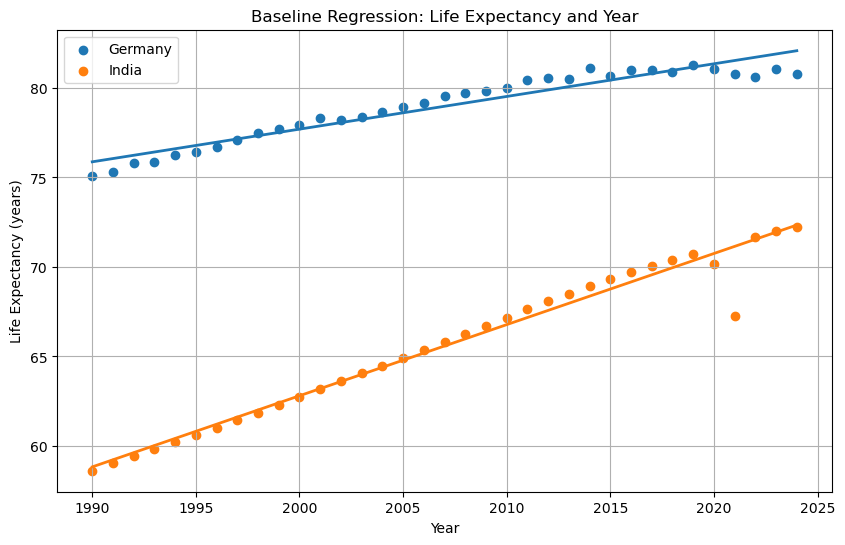

In [34]:
plt.figure(figsize=(10, 6))

# Germany
plt.scatter(
    X_germany,
    y_germany,
    label="Germany"
)

plt.plot(
    X_germany,
    y_pred_germany,
    linewidth=2
)

# India
plt.scatter(
    X_india,
    y_india,
    label="India"
)

plt.plot(
    X_india,
    y_pred_india,
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("Baseline Regression: Life Expectancy and Year")
plt.legend()
plt.grid(True)

plt.savefig(
    "figures/baseline_life_expectancy_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
baseline_results.to_csv(
    "baseline_regression_results.csv",
    index=False
)

In [36]:
baseline_results

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901
1,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


# Model 1: Healthcare Accessibility

This model examines the association between healthcare accessibility indicators and life expectancy separately for Germany and India.

The dependent variable is Life Expectancy. The explanatory variables are Physician Density, Hospital Beds per 1,000 Population, Health Expenditure, and Out-of-Pocket Expenditure.

Separate models are estimated for Germany and India to account for differences in their healthcare systems and development trajectories.

Because the analysis uses observational data, coefficients are interpreted as associations rather than causal effects.

In [38]:
germany_model1 = df[
    df["Country"] == "Germany"
][[
    "Year",
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]].copy()

germany_model1.head()

,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
0,1990,75.085634,2.745,10.4,8.404808,14.119194
1,1991,75.319512,2.745,10.1,8.516111,14.041934
2,1992,75.819512,2.816,9.9,8.627414,13.964675
3,1993,75.870732,2.904,9.7,8.738717,13.887415
4,1994,76.270732,2.977,9.7,8.850019,13.810155


In [39]:
germany_model1.isnull().sum()

Year                      0
Life_Expectancy           0
Physician_Density         0
Hospital_Beds_Per_1000    0
Health_Expenditure_y      0
Out_of_Pocket             0
dtype: int64

In [40]:
germany_model1.shape

(35, 6)

In [41]:
X_germany_1 = germany_model1[
    [
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_germany_1 = germany_model1["Life_Expectancy"]

In [42]:
model1_germany = LinearRegression()

model1_germany.fit(
    X_germany_1,
    y_germany_1
)

LinearRegression()

In [43]:
y_pred_germany_1 = model1_germany.predict(X_germany_1)

In [44]:
r2_germany_1 = r2_score(
    y_germany_1,
    y_pred_germany_1
)

print("Germany Model 1 R²:", r2_germany_1)

Germany Model 1 R²: 0.9647745454594101


In [45]:
n_germany = len(y_germany_1)
p_germany = X_germany_1.shape[1]

adjusted_r2_germany_1 = (
    1 - (1 - r2_germany_1)
    * (n_germany - 1)
    / (n_germany - p_germany - 1)
)

print("Germany Adjusted R²:", adjusted_r2_germany_1)

Germany Adjusted R²: 0.9600778181873314


In [46]:
from sklearn.metrics import mean_absolute_error

mae_germany_1 = mean_absolute_error(
    y_germany_1,
    y_pred_germany_1
)

print("Germany MAE:", mae_germany_1)

Germany MAE: 0.2973156422439794


In [47]:
rmse_germany_1 = np.sqrt(
    mean_squared_error(
        y_germany_1,
        y_pred_germany_1
    )
)

print("Germany RMSE:", rmse_germany_1)

Germany RMSE: 0.3602544594656243


In [48]:
coefficients_germany = pd.DataFrame({
    "Predictor": X_germany_1.columns,
    "Coefficient": model1_germany.coef_
})

coefficients_germany

,Predictor,Coefficient
0,Physician_Density,1.609173
1,Hospital_Beds_Per_1000,-2.076954
2,Health_Expenditure_y,-0.468599
3,Out_of_Pocket,0.148249


In [49]:
print("Germany Intercept:", model1_germany.intercept_)

Germany Intercept: 94.0144042435228


In [50]:
import statsmodels.api as sm

In [51]:
X_germany_sm = sm.add_constant(X_germany_1)

ols_germany_1 = sm.OLS(
    y_germany_1,
    X_germany_sm
).fit()

print(ols_germany_1.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     205.4
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.47e-21
Time:                        17:00:46   Log-Likelihood:                -13.930
No. Observations:                  35   AIC:                             37.86
Df Residuals:                      30   BIC:                             45.64
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     94

In [52]:
germany_coefficients = pd.DataFrame({
    "Coefficient": ols_germany_1.params,
    "P_Value": ols_germany_1.pvalues,
    "CI_Lower": ols_germany_1.conf_int()[0],
    "CI_Upper": ols_germany_1.conf_int()[1]
})

germany_coefficients

,Coefficient,P_Value,CI_Lower,CI_Upper
const,94.014404,2.265249e-16,82.155168,105.873641
Physician_Density,1.609173,4.994316e-03,0.524651,2.693694
Hospital_Beds_Per_1000,-2.076954,2.049665e-07,-2.710760,-1.443149
Health_Expenditure_y,-0.468599,7.126420e-02,-0.980355,0.043157
Out_of_Pocket,0.148249,2.321500e-01,-0.100018,0.396516


In [53]:
germany_coefficients.to_csv(
    "germany_model1_coefficients.csv"
)

In [54]:
germany_model1_summary = pd.DataFrame({
    "Country": ["Germany"],
    "Model": ["Model 1 - Healthcare Accessibility"],
    "R2": [ols_germany_1.rsquared],
    "Adjusted_R2": [ols_germany_1.rsquared_adj],
    "MAE": [mae_germany_1],
    "RMSE": [rmse_germany_1]
})

germany_model1_summary

,Country,Model,R2,Adjusted_R2,MAE,RMSE
0,Germany,Model 1 - Healthcare Accessibility,0.964775,0.960078,0.297316,0.360254


In [55]:
germany_model1_summary.to_csv(
    "germany_model1_summary.csv",
    index=False
)

In [56]:
india_model1 = df[
    df["Country"] == "India"
][[
    "Year",
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]].copy()

india_model1.head()

,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
35,1990,58.618,1.231000,0.769800,4.544816,91.589157
36,1991,59.032,1.231000,0.787000,4.499428,90.265202
37,1992,59.445,1.208565,0.936222,4.454041,88.941247
38,1993,59.823,1.186130,1.085444,4.408654,87.617293
39,1994,60.237,1.163696,1.234667,4.363266,86.293338


In [57]:
india_model1.isnull().sum()

Year                      0
Life_Expectancy           0
Physician_Density         0
Hospital_Beds_Per_1000    0
Health_Expenditure_y      0
Out_of_Pocket             0
dtype: int64

In [58]:
india_model1.shape

(35, 6)

In [59]:
X_india_1 = india_model1[
    [
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_india_1 = india_model1["Life_Expectancy"]

In [60]:
model1_india = LinearRegression()

model1_india.fit(
    X_india_1,
    y_india_1
)

LinearRegression()

In [61]:
y_pred_india_1 = model1_india.predict(X_india_1)

In [62]:
r2_india_1 = r2_score(
    y_india_1,
    y_pred_india_1
)

print("India Model 1 R²:", r2_india_1)

India Model 1 R²: 0.9566286169878566


In [63]:
n_india = len(y_india_1)
p_india = X_india_1.shape[1]

adjusted_r2_india_1 = (
    1 - (1 - r2_india_1)
    * (n_india - 1)
    / (n_india - p_india - 1)
)

print("India Model 1 Adjusted R²:", adjusted_r2_india_1)

India Model 1 Adjusted R²: 0.9508457659195708


In [64]:
mae_india_1 = mean_absolute_error(
    y_india_1,
    y_pred_india_1
)

print("India Model 1 MAE:", mae_india_1)

India Model 1 MAE: 0.5342395473491028


In [65]:
rmse_india_1 = np.sqrt(
    mean_squared_error(
        y_india_1,
        y_pred_india_1
    )
)

print("India Model 1 RMSE:", rmse_india_1)

India Model 1 RMSE: 0.8491077013268981


In [66]:
X_india_sm = sm.add_constant(X_india_1)

ols_india_1 = sm.OLS(
    y_india_1,
    X_india_sm
).fit()

print(ols_india_1.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     165.4
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           5.55e-20
Time:                        17:00:51   Log-Likelihood:                -43.938
No. Observations:                  35   AIC:                             97.88
Df Residuals:                      30   BIC:                             105.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     90

In [67]:
india_coefficients = pd.DataFrame({
    "Coefficient": ols_india_1.params,
    "P_Value": ols_india_1.pvalues,
    "CI_Lower": ols_india_1.conf_int()[0],
    "CI_Upper": ols_india_1.conf_int()[1]
})

india_coefficients

,Coefficient,P_Value,CI_Lower,CI_Upper
const,90.781016,7.844049e-31,87.180141,94.381890
Physician_Density,-11.212031,2.674872e-05,-15.836908,-6.587154
Hospital_Beds_Per_1000,-0.473051,3.882955e-01,-1.576622,0.630520
Health_Expenditure_y,-2.051838,1.036116e-02,-3.583781,-0.519895
Out_of_Pocket,-0.092134,3.686721e-03,-0.151876,-0.032392


In [68]:
india_coefficients.to_csv(
    "india_model1_coefficients.csv"
)

In [69]:
india_model1_summary = pd.DataFrame({
    "Country": ["India"],
    "Model": ["Model 1 - Healthcare Accessibility"],
    "R2": [ols_india_1.rsquared],
    "Adjusted_R2": [ols_india_1.rsquared_adj],
    "MAE": [mae_india_1],
    "RMSE": [rmse_india_1]
})

india_model1_summary

,Country,Model,R2,Adjusted_R2,MAE,RMSE
0,India,Model 1 - Healthcare Accessibility,0.956629,0.950846,0.53424,0.849108


In [70]:
india_model1_summary.to_csv(
    "india_model1_summary.csv",
    index=False
)

## Model 1 Diagnostic Analysis: Multicollinearity

Before interpreting individual regression coefficients, multicollinearity among the healthcare accessibility predictors is assessed using correlation matrices and Variance Inflation Factors (VIF).

In [72]:
germany_corr = X_germany_1.corr()

germany_corr

,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
Physician_Density,1.000000,-0.953820,0.964540,-0.780782
Hospital_Beds_Per_1000,-0.953820,1.000000,-0.936366,0.697070
Health_Expenditure_y,0.964540,-0.936366,1.000000,-0.820788
Out_of_Pocket,-0.780782,0.697070,-0.820788,1.000000


In [73]:
india_corr = X_india_1.corr()

india_corr

,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
Physician_Density,1.000000,-0.474890,0.861646,0.884450
Hospital_Beds_Per_1000,-0.474890,1.000000,-0.298889,-0.342066
Health_Expenditure_y,0.861646,-0.298889,1.000000,0.894536
Out_of_Pocket,0.884450,-0.342066,0.894536,1.000000


In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_germany_vif = sm.add_constant(X_germany_1)

vif_germany = pd.DataFrame()

vif_germany["Variable"] = X_germany_vif.columns

vif_germany["VIF"] = [
    variance_inflation_factor(
        X_germany_vif.values,
        i
    )
    for i in range(X_germany_vif.shape[1])
]

vif_germany

,Variable,VIF
0,const,7794.506207
1,Physician_Density,20.992373
2,Hospital_Beds_Per_1000,13.525365
3,Health_Expenditure_y,19.709281
4,Out_of_Pocket,3.599282


In [75]:
X_india_vif = sm.add_constant(X_india_1)

vif_india = pd.DataFrame()

vif_india["Variable"] = X_india_vif.columns

vif_india["VIF"] = [
    variance_inflation_factor(
        X_india_vif.values,
        i
    )
    for i in range(X_india_vif.shape[1])
]

vif_india

,Variable,VIF
0,const,129.355323
1,Physician_Density,6.318903
2,Hospital_Beds_Per_1000,1.380769
3,Health_Expenditure_y,5.824072
4,Out_of_Pocket,6.710766


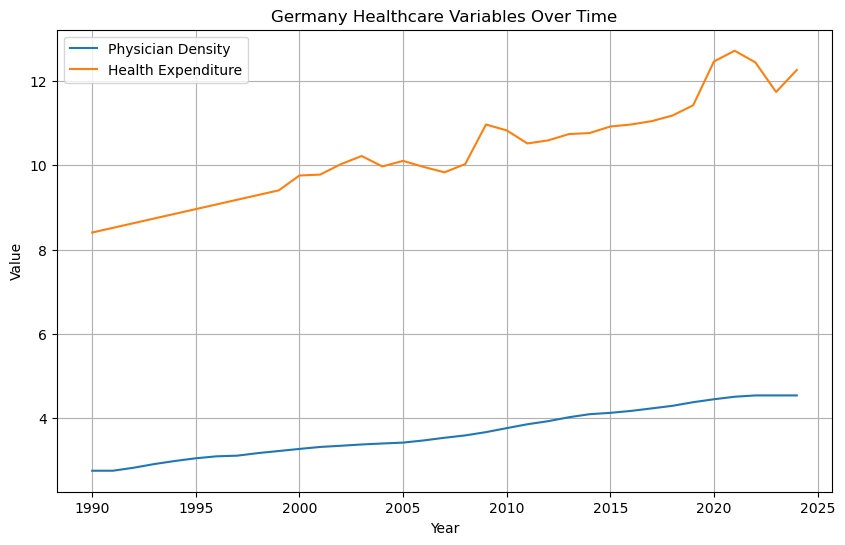

In [76]:
plt.figure(figsize=(10, 6))

plt.plot(
    germany_model1["Year"],
    germany_model1["Physician_Density"],
    label="Physician Density"
)

plt.plot(
    germany_model1["Year"],
    germany_model1["Health_Expenditure_y"],
    label="Health Expenditure"
)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Germany Healthcare Variables Over Time")
plt.legend()
plt.grid(True)

plt.show()

In [77]:
vif_germany

,Variable,VIF
0,const,7794.506207
1,Physician_Density,20.992373
2,Hospital_Beds_Per_1000,13.525365
3,Health_Expenditure_y,19.709281
4,Out_of_Pocket,3.599282


In [78]:
vif_india

,Variable,VIF
0,const,129.355323
1,Physician_Density,6.318903
2,Hospital_Beds_Per_1000,1.380769
3,Health_Expenditure_y,5.824072
4,Out_of_Pocket,6.710766


# Model 1B: Time-Adjusted Healthcare Accessibility

Model 1B extends the healthcare accessibility model by including Year as a predictor.

This allows us to examine whether healthcare accessibility indicators are associated with life expectancy beyond the underlying long-term temporal trend.

Because the data are observational and the predictors may be correlated with time, coefficients are interpreted as associations rather than causal effects.

In [80]:
X_germany_1b = germany_model1[
    [
        "Year",
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_germany_1b = germany_model1["Life_Expectancy"]

X_germany_1b_sm = sm.add_constant(X_germany_1b)

ols_germany_1b = sm.OLS(
    y_germany_1b,
    X_germany_1b_sm
).fit()

print(ols_germany_1b.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     167.5
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.81e-20
Time:                        17:00:55   Log-Likelihood:                -13.031
No. Observations:                  35   AIC:                             38.06
Df Residuals:                      29   BIC:                             47.39
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    436

In [81]:
X_india_1b = india_model1[
    [
        "Year",
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_india_1b = india_model1["Life_Expectancy"]

X_india_1b_sm = sm.add_constant(X_india_1b)

ols_india_1b = sm.OLS(
    y_india_1b,
    X_india_1b_sm
).fit()

print(ols_india_1b.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     276.8
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.54e-23
Time:                        17:00:55   Log-Likelihood:                -30.842
No. Observations:                  35   AIC:                             73.68
Df Residuals:                      29   BIC:                             83.02
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -1018

In [82]:
X_germany_1b_vif = sm.add_constant(X_germany_1b)

vif_germany_1b = pd.DataFrame({
    "Variable": X_germany_1b_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_germany_1b_vif.values,
            i
        )
        for i in range(X_germany_1b_vif.shape[1])
    ]
})

vif_germany_1b

,Variable,VIF
0,const,1.802522e+07
1,Year,4.620876e+02
2,Physician_Density,2.449365e+02
3,Hospital_Beds_Per_1000,5.678354e+01
4,Health_Expenditure_y,1.977716e+01
5,Out_of_Pocket,3.619539e+00


In [83]:
X_india_1b_vif = sm.add_constant(X_india_1b)

vif_india_1b = pd.DataFrame({
    "Variable": X_india_1b_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_india_1b_vif.values,
            i
        )
        for i in range(X_india_1b_vif.shape[1])
    ]
})

vif_india_1b

,Variable,VIF
0,const,3.242471e+06
1,Year,7.734477e+01
2,Physician_Density,1.946417e+01
3,Hospital_Beds_Per_1000,1.776286e+00
4,Health_Expenditure_y,6.468789e+00
5,Out_of_Pocket,3.029111e+01


In [84]:
features = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]

train_germany = germany_model1[
    germany_model1["Year"] <= 2016
].copy()

test_germany = germany_model1[
    germany_model1["Year"] > 2016
].copy()

X_train = train_germany[features]
y_train = train_germany["Life_Expectancy"]

X_test = test_germany[features]
y_test = test_germany["Life_Expectancy"]

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

model_germany = LinearRegression()

model_germany.fit(X_train, y_train)

y_pred = model_germany.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Germany Test R²:", test_r2)
print("Germany Test MAE:", test_mae)
print("Germany Test RMSE:", test_rmse)

Germany Test R²: -52.438904923423365
Germany Test MAE: 1.2944232000477243
Germany Test RMSE: 1.4243887814998504


In [86]:
train_india = india_model1[
    india_model1["Year"] <= 2016
].copy()

test_india = india_model1[
    india_model1["Year"] > 2016
].copy()

X_train = train_india[features]
y_train = train_india["Life_Expectancy"]

X_test = test_india[features]
y_test = test_india["Life_Expectancy"]

model_india = LinearRegression()

model_india.fit(X_train, y_train)

y_pred = model_india.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("India Test R²:", test_r2)
print("India Test MAE:", test_mae)
print("India Test RMSE:", test_rmse)

India Test R²: -2.0557209496210147
India Test MAE: 2.2817488064955924
India Test RMSE: 2.5770736209394753


# Model 1 — Out-of-Sample Evaluation and Diagnostics

Model 1 predicts Life Expectancy using healthcare accessibility and healthcare financing indicators.

The purpose of this section is to evaluate whether the model can generalize to previously unseen observations rather than only explaining the historical data used during model fitting.

A chronological train-test split is used because the dataset represents a time series. Random splitting is avoided because it could allow information from later years to influence model training.

In [88]:
features = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]

target = "Life_Expectancy"

In [89]:
train_germany = germany_model1[
    germany_model1["Year"] <= 2016
].copy()

test_germany = germany_model1[
    germany_model1["Year"] > 2016
].copy()

print("Germany training years:",
      train_germany["Year"].min(),
      "to",
      train_germany["Year"].max())

print("Germany testing years:",
      test_germany["Year"].min(),
      "to",
      test_germany["Year"].max())

Germany training years: 1990 to 2016
Germany testing years: 2017 to 2024


In [90]:
X_train_germany = train_germany[features]
y_train_germany = train_germany[target]

X_test_germany = test_germany[features]
y_test_germany = test_germany[target]

In [91]:
from sklearn.linear_model import LinearRegression

model1_germany = LinearRegression()

model1_germany.fit(
    X_train_germany,
    y_train_germany
)

LinearRegression()

In [92]:
y_pred_germany = model1_germany.predict(
    X_test_germany
)

In [93]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2_germany = r2_score(
    y_test_germany,
    y_pred_germany
)

mae_germany = mean_absolute_error(
    y_test_germany,
    y_pred_germany
)

rmse_germany = mean_squared_error(
    y_test_germany,
    y_pred_germany
) ** 0.5

print("Germany Model 1")
print("----------------")
print("Test R²:", round(r2_germany, 4))
print("Test MAE:", round(mae_germany, 4))
print("Test RMSE:", round(rmse_germany, 4))

Germany Model 1
----------------
Test R²: -52.4389
Test MAE: 1.2944
Test RMSE: 1.4244


In [94]:
train_india = india_model1[
    india_model1["Year"] <= 2016
].copy()

test_india = india_model1[
    india_model1["Year"] > 2016
].copy()

print("India training years:",
      train_india["Year"].min(),
      "to",
      train_india["Year"].max())

print("India testing years:",
      test_india["Year"].min(),
      "to",
      test_india["Year"].max())

India training years: 1990 to 2016
India testing years: 2017 to 2024


In [95]:
X_train_india = train_india[features]
y_train_india = train_india[target]

X_test_india = test_india[features]
y_test_india = test_india[target]

In [96]:
model1_india = LinearRegression()

model1_india.fit(
    X_train_india,
    y_train_india
)

LinearRegression()

In [97]:
y_pred_india = model1_india.predict(
    X_test_india
)

In [98]:
r2_india = r2_score(
    y_test_india,
    y_pred_india
)

mae_india = mean_absolute_error(
    y_test_india,
    y_pred_india
)

rmse_india = mean_squared_error(
    y_test_india,
    y_pred_india
) ** 0.5

print("India Model 1")
print("----------------")
print("Test R²:", round(r2_india, 4))
print("Test MAE:", round(mae_india, 4))
print("Test RMSE:", round(rmse_india, 4))

India Model 1
----------------
Test R²: -2.0557
Test MAE: 2.2817
Test RMSE: 2.5771


# Forecasting Analysis

## Model 0 — Naive Forecast Baseline

The naive forecasting model is used as a baseline for evaluating more advanced forecasting methods.

For each prediction period, the forecast is based on the most recently observed life expectancy value.

The purpose of this model is not to provide the final forecast, but to establish a simple benchmark against which more complex forecasting methods can be compared.

In [100]:
print(germany_model1.columns.tolist())

['Year', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Health_Expenditure_y', 'Out_of_Pocket']


In [101]:
print(india_model1.columns.tolist())

['Year', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Health_Expenditure_y', 'Out_of_Pocket']


In [102]:
germany_model1[["Year", "Life_Expectancy"]].head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [103]:
india_model1[["Year", "Life_Expectancy"]].head()

,Year,Life_Expectancy
35,1990,58.618
36,1991,59.032
37,1992,59.445
38,1993,59.823
39,1994,60.237


In [104]:
print("Germany")
print("First year:", germany_model1["Year"].min())
print("Last year:", germany_model1["Year"].max())
print("Number of observations:", germany_model1["Year"].nunique())

Germany
First year: 1990
Last year: 2024
Number of observations: 35


In [105]:
print("India")
print("First year:", india_model1["Year"].min())
print("Last year:", india_model1["Year"].max())
print("Number of observations:", india_model1["Year"].nunique())

India
First year: 1990
Last year: 2024
Number of observations: 35


In [106]:
print("Germany missing values:")
print(germany_model1[["Year", "Life_Expectancy"]].isnull().sum())

print("\nIndia missing values:")
print(india_model1[["Year", "Life_Expectancy"]].isnull().sum())

Germany missing values:
Year               0
Life_Expectancy    0
dtype: int64

India missing values:
Year               0
Life_Expectancy    0
dtype: int64


In [107]:
germany_forecast = germany_model1[
    ["Year", "Life_Expectancy"]
].copy()

germany_forecast = germany_forecast.sort_values("Year").reset_index(drop=True)

In [108]:
india_forecast = india_model1[
    ["Year", "Life_Expectancy"]
].copy()

india_forecast = india_forecast.sort_values("Year").reset_index(drop=True)

In [109]:
germany_forecast.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [110]:
germany_forecast.tail()

,Year,Life_Expectancy
30,2020,81.041463
31,2021,80.790244
32,2022,80.608049
33,2023,81.041463
34,2024,80.792683


In [111]:
india_forecast.head()

,Year,Life_Expectancy
0,1990,58.618
1,1991,59.032
2,1992,59.445
3,1993,59.823
4,1994,60.237


In [112]:
india_forecast.tail()

,Year,Life_Expectancy
30,2020,70.156
31,2021,67.282
32,2022,71.698
33,2023,72.003
34,2024,72.235


In [113]:
germany_split = int(len(germany_forecast) * 0.8)
india_split = int(len(india_forecast) * 0.8)

print("Germany split:", germany_split)
print("India split:", india_split)

Germany split: 28
India split: 28


In [114]:
germany_train = germany_forecast.iloc[:germany_split].copy()
germany_test = germany_forecast.iloc[germany_split:].copy()

In [115]:
india_train = india_forecast.iloc[:india_split].copy()
india_test = india_forecast.iloc[india_split:].copy()

In [116]:
print(
    "Germany training:",
    germany_train["Year"].min(),
    "to",
    germany_train["Year"].max()
)

print(
    "Germany testing:",
    germany_test["Year"].min(),
    "to",
    germany_test["Year"].max()
)

Germany training: 1990 to 2017
Germany testing: 2018 to 2024


In [117]:
print(
    "India training:",
    india_train["Year"].min(),
    "to",
    india_train["Year"].max()
)

print(
    "India testing:",
    india_test["Year"].min(),
    "to",
    india_test["Year"].max()
)

India training: 1990 to 2017
India testing: 2018 to 2024


In [118]:
germany_last_value = germany_train["Life_Expectancy"].iloc[-1]

germany_test["Naive_Forecast"] = germany_last_value

print("Germany naive forecast:", germany_last_value)

Germany naive forecast: 80.99268293


In [119]:
india_last_value = india_train["Life_Expectancy"].iloc[-1]

india_test["Naive_Forecast"] = india_last_value

print("India naive forecast:", india_last_value)

India naive forecast: 70.068


In [120]:
germany_test

,Year,Life_Expectancy,Naive_Forecast
28,2018,80.892683,80.992683
29,2019,81.292683,80.992683
30,2020,81.041463,80.992683
31,2021,80.790244,80.992683
32,2022,80.608049,80.992683
33,2023,81.041463,80.992683
34,2024,80.792683,80.992683


In [121]:
india_test

,Year,Life_Expectancy,Naive_Forecast
28,2018,70.415,70.068
29,2019,70.746,70.068
30,2020,70.156,70.068
31,2021,67.282,70.068
32,2022,71.698,70.068
33,2023,72.003,70.068
34,2024,72.235,70.068


In [122]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [123]:
germany_naive_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
)

germany_naive_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
) ** 0.5

germany_naive_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
)

print("Germany Naive Forecast")
print("----------------------")
print("MAE:", round(germany_naive_mae, 4))
print("RMSE:", round(germany_naive_rmse, 4))
print("R²:", round(germany_naive_r2, 4))

Germany Naive Forecast
----------------------
MAE: 0.1835
RMSE: 0.2183
R²: -0.1143


In [124]:
india_naive_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
)

india_naive_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
) ** 0.5

india_naive_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
)

print("India Naive Forecast")
print("--------------------")
print("MAE:", round(india_naive_mae, 4))
print("RMSE:", round(india_naive_rmse, 4))
print("R²:", round(india_naive_r2, 4))

India Naive Forecast
--------------------
MAE: 1.3759
RMSE: 1.6668
R²: -0.1377


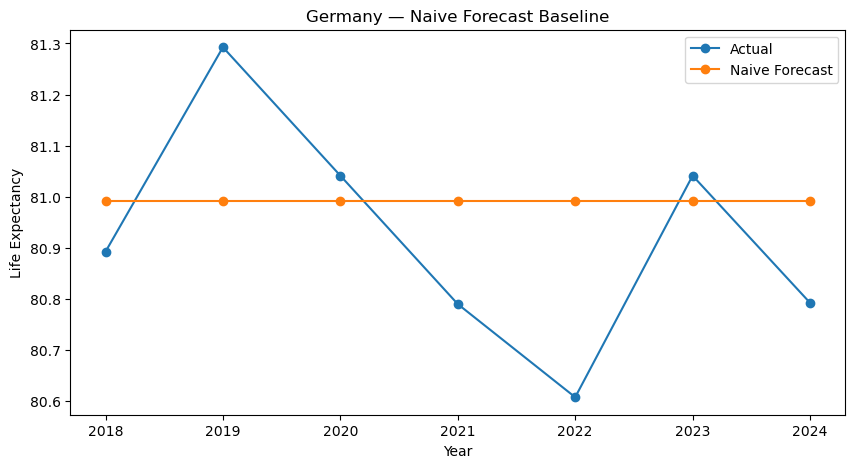

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive Forecast"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Naive Forecast Baseline")
plt.legend()

plt.show()

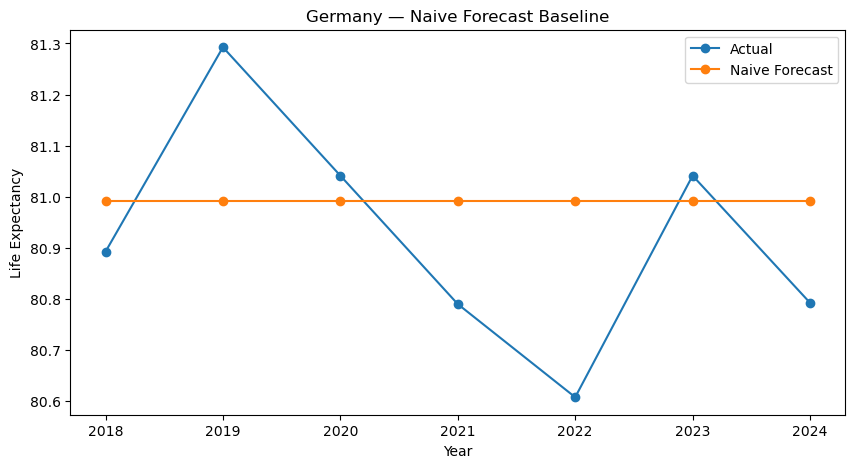

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive Forecast"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Naive Forecast Baseline")
plt.legend()

plt.show()

In [127]:
forecast_results = pd.DataFrame({
    "Model": ["Naive"],
    "Germany_MAE": [germany_naive_mae],
    "Germany_RMSE": [germany_naive_rmse],
    "India_MAE": [india_naive_mae],
    "India_RMSE": [india_naive_rmse]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761


## Model 1 — Linear Trend Forecast

A linear trend model is used to establish whether the historical trend in life expectancy provides a more informative forecasting signal than the naive persistence baseline.

The model is trained only on the training period and evaluated on the same unseen test period used for the naive baseline.

In [129]:
from sklearn.linear_model import LinearRegression

trend_model_germany = LinearRegression()

X_train_year_germany = germany_train[["Year"]]
y_train_life_germany = germany_train["Life_Expectancy"]

trend_model_germany.fit(
    X_train_year_germany,
    y_train_life_germany
)

LinearRegression()

In [130]:
germany_trend_pred = trend_model_germany.predict(
    germany_test[["Year"]]
)

In [131]:
germany_trend_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_trend_pred
)

germany_trend_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_trend_pred
) ** 0.5

germany_trend_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_trend_pred
)

print("Germany Linear Trend")
print("--------------------")
print("MAE:", round(germany_trend_mae, 4))
print("RMSE:", round(germany_trend_rmse, 4))
print("R²:", round(germany_trend_r2, 4))

Germany Linear Trend
--------------------
MAE: 1.5293
RMSE: 1.6331
R²: -61.3423


In [132]:
trend_model_india = LinearRegression()

X_train_year_india = india_train[["Year"]]
y_train_life_india = india_train["Life_Expectancy"]

trend_model_india.fit(
    X_train_year_india,
    y_train_life_india
)

LinearRegression()

In [133]:
india_trend_pred = trend_model_india.predict(
    india_test[["Year"]]
)

In [134]:
india_trend_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_trend_pred
)

india_trend_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_trend_pred
) ** 0.5

india_trend_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_trend_pred
)

print("India Linear Trend")
print("------------------")
print("MAE:", round(india_trend_mae, 4))
print("RMSE:", round(india_trend_rmse, 4))
print("R²:", round(india_trend_r2, 4))

India Linear Trend
------------------
MAE: 1.2263
RMSE: 1.8755
R²: -0.4405


In [135]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490


## Model 2 — Holt's Exponential Smoothing

Holt's exponential smoothing method is evaluated to determine whether incorporating both the current level and evolving trend of life expectancy improves forecasting performance compared with the naive and linear trend baselines.

The model is evaluated using the same chronological test period as the previous forecasting models.

In [137]:
from statsmodels.tsa.holtwinters import Holt

In [138]:
holt_germany = Holt(
    germany_train["Life_Expectancy"],
    initialization_method="estimated"
).fit()

In [139]:
germany_holt_pred = holt_germany.forecast(
    len(germany_test)
)

In [140]:
germany_holt_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_holt_pred
)

germany_holt_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_holt_pred
) ** 0.5

germany_holt_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_holt_pred
)

print("Germany Holt")
print("------------")
print("MAE:", round(germany_holt_mae, 4))
print("RMSE:", round(germany_holt_rmse, 4))
print("R²:", round(germany_holt_r2, 4))

Germany Holt
------------
MAE: 0.6682
RMSE: 0.7715
R²: -12.9154


In [141]:
holt_india = Holt(
    india_train["Life_Expectancy"],
    initialization_method="estimated"
).fit()

In [142]:
india_holt_pred = holt_india.forecast(
    len(india_test)
)

In [143]:
india_holt_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_holt_pred
)

india_holt_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_holt_pred
) ** 0.5

india_holt_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_holt_pred
)

print("India Holt")
print("----------")
print("MAE:", round(india_holt_mae, 4))
print("RMSE:", round(india_holt_rmse, 4))
print("R²:", round(india_holt_r2, 4))

India Holt
----------
MAE: 0.8904
RMSE: 1.6659
R²: -0.1365


In [144]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend",
        "Holt"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae,
        germany_holt_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse,
        germany_holt_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae,
        india_holt_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse,
        india_holt_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490
2,Holt,0.668192,0.771547,0.890374,1.665916


## Forecast Model Comparison — Germany

The following visualization compares the actual life-expectancy values during the test period with predictions from the Naive, Linear Trend, and Holt forecasting models.

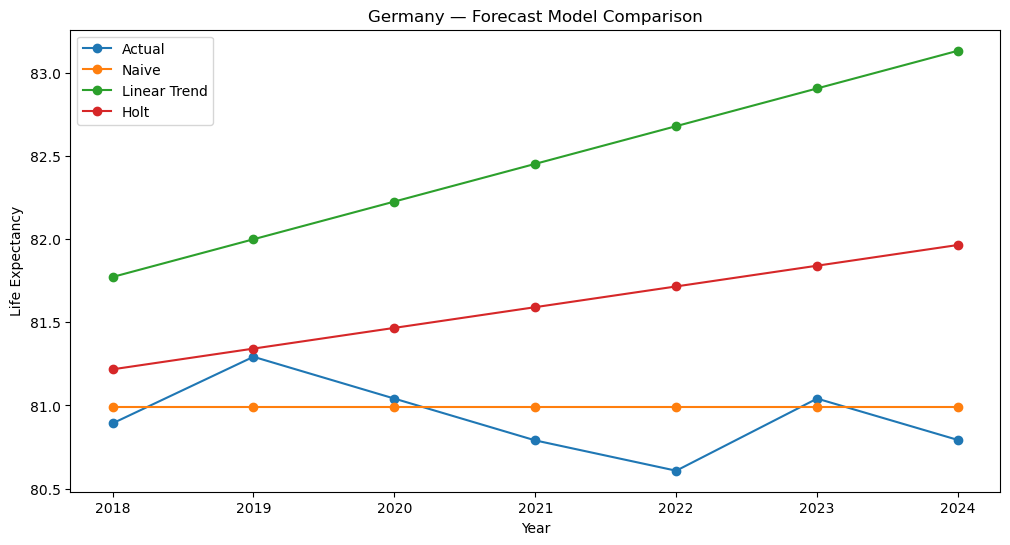

In [146]:
plt.figure(figsize=(12, 6))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive"
)

plt.plot(
    germany_test["Year"],
    germany_trend_pred,
    marker="o",
    label="Linear Trend"
)

plt.plot(
    germany_test["Year"],
    germany_holt_pred,
    marker="o",
    label="Holt"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Forecast Model Comparison")
plt.legend()

plt.show()

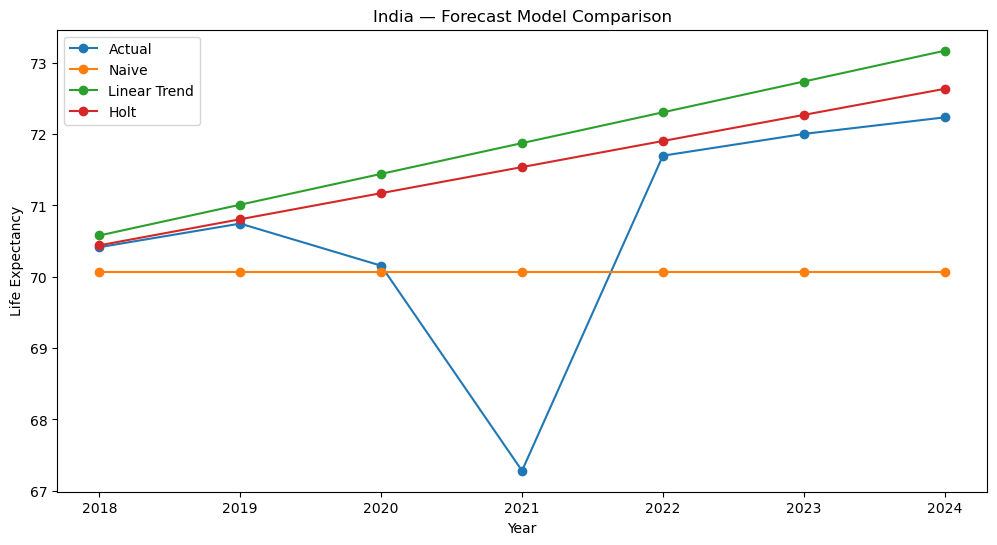

In [147]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_test["Year"],
    india_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    india_test["Year"],
    india_test["Naive_Forecast"],
    marker="o",
    label="Naive"
)

plt.plot(
    india_test["Year"],
    india_trend_pred,
    marker="o",
    label="Linear Trend"
)

plt.plot(
    india_test["Year"],
    india_holt_pred,
    marker="o",
    label="Holt"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("India — Forecast Model Comparison")
plt.legend()

plt.show()

In [148]:
germany_forecast_comparison = pd.DataFrame({
    "Year": germany_test["Year"].values,
    "Actual": germany_test["Life_Expectancy"].values,
    "Naive": germany_test["Naive_Forecast"].values,
    "Linear_Trend": germany_trend_pred,
    "Holt": germany_holt_pred
})

germany_forecast_comparison

,Year,Actual,Naive,Linear_Trend,Holt
28,2018,80.892683,80.992683,81.772242,81.217304
29,2019,81.292683,80.992683,81.998844,81.341851
30,2020,81.041463,80.992683,82.225446,81.466398
31,2021,80.790244,80.992683,82.452049,81.590945
32,2022,80.608049,80.992683,82.678651,81.715492
33,2023,81.041463,80.992683,82.905253,81.840039
34,2024,80.792683,80.992683,83.131856,81.964586


In [149]:
india_forecast_comparison = pd.DataFrame({
    "Year": india_test["Year"].values,
    "Actual": india_test["Life_Expectancy"].values,
    "Naive": india_test["Naive_Forecast"].values,
    "Linear_Trend": india_trend_pred,
    "Holt": india_holt_pred
})

india_forecast_comparison

,Year,Actual,Naive,Linear_Trend,Holt
28,2018,70.415,70.068,70.579254,70.441215
29,2019,70.746,70.068,71.010902,70.806887
30,2020,70.156,70.068,71.442550,71.172559
31,2021,67.282,70.068,71.874198,71.538231
32,2022,71.698,70.068,72.305846,71.903903
33,2023,72.003,70.068,72.737494,72.269575
34,2024,72.235,70.068,73.169142,72.635247


## Model 3 — ARIMA Forecast

An ARIMA model is evaluated as an additional time-series forecasting approach. 
The model is trained on the same historical training period used for the Naive, 
Linear Trend, and Holt models and evaluated on the same unseen test period.

ARIMA is tested to determine whether explicitly modelling temporal dependence 
and differenced trends improves out-of-sample forecasting performance.

In [151]:
from statsmodels.tsa.arima.model import ARIMA

In [152]:
arima_germany = ARIMA(
    germany_train["Life_Expectancy"],
    order=(1, 1, 0)
)

arima_germany_fit = arima_germany.fit()

In [153]:
germany_arima_pred = arima_germany_fit.forecast(
    steps=len(germany_test)
)

In [154]:
germany_arima_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_arima_pred
)

germany_arima_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_arima_pred
) ** 0.5

germany_arima_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_arima_pred
)

print("Germany ARIMA(1,1,0)")
print("-------------------")
print("MAE:", round(germany_arima_mae, 4))
print("RMSE:", round(germany_arima_rmse, 4))
print("R²:", round(germany_arima_r2, 4))

Germany ARIMA(1,1,0)
-------------------
MAE: 0.1836
RMSE: 0.2186
R²: -0.1175


In [155]:
arima_india = ARIMA(
    india_train["Life_Expectancy"],
    order=(1, 1, 0)
)

arima_india_fit = arima_india.fit()

In [156]:
india_arima_pred = arima_india_fit.forecast(
    steps=len(india_test)
)

In [157]:
india_arima_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_arima_pred
)

india_arima_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_arima_pred
) ** 0.5

india_arima_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_arima_pred
)

print("India ARIMA(1,1,0)")
print("-----------------")
print("MAE:", round(india_arima_mae, 4))
print("RMSE:", round(india_arima_rmse, 4))
print("R²:", round(india_arima_r2, 4))

India ARIMA(1,1,0)
-----------------
MAE: 0.8253
RMSE: 1.6334
R²: -0.0926


In [158]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend",
        "Holt",
        "ARIMA(1,1,0)"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae,
        germany_holt_mae,
        germany_arima_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse,
        germany_holt_rmse,
        germany_arima_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae,
        india_holt_mae,
        india_arima_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse,
        india_holt_rmse,
        india_arima_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490
2,Holt,0.668192,0.771547,0.890374,1.665916
3,"ARIMA(1,1,0)",0.183632,0.218642,0.825283,1.633368


In [159]:
arima_germany_011 = ARIMA(
    germany_train["Life_Expectancy"],
    order=(0, 1, 1)
).fit()

germany_arima_011_pred = arima_germany_011.forecast(
    steps=len(germany_test)
)

print(
    "Germany ARIMA(0,1,1) MAE:",
    mean_absolute_error(
        germany_test["Life_Expectancy"],
        germany_arima_011_pred
    )
)

print(
    "Germany ARIMA(0,1,1) RMSE:",
    mean_squared_error(
        germany_test["Life_Expectancy"],
        germany_arima_011_pred
    ) ** 0.5
)

Germany ARIMA(0,1,1) MAE: 0.18213487452150495
Germany ARIMA(0,1,1) RMSE: 0.215424687228584


In [160]:
arima_india_011 = ARIMA(
    india_train["Life_Expectancy"],
    order=(0, 1, 1)
).fit()

india_arima_011_pred = arima_india_011.forecast(
    steps=len(india_test)
)

print(
    "India ARIMA(0,1,1) MAE:",
    mean_absolute_error(
        india_test["Life_Expectancy"],
        india_arima_011_pred
    )
)

print(
    "India ARIMA(0,1,1) RMSE:",
    mean_squared_error(
        india_test["Life_Expectancy"],
        india_arima_011_pred
    ) ** 0.5
)

India ARIMA(0,1,1) MAE: 1.29887731384749
India ARIMA(0,1,1) RMSE: 1.628634764159593


In [161]:
arima_germany_111 = ARIMA(
    germany_train["Life_Expectancy"],
    order=(1, 1, 1)
).fit()

germany_arima_111_pred = arima_germany_111.forecast(
    steps=len(germany_test)
)

print(
    "Germany ARIMA(1,1,1) MAE:",
    mean_absolute_error(
        germany_test["Life_Expectancy"],
        germany_arima_111_pred
    )
)

print(
    "Germany ARIMA(1,1,1) RMSE:",
    mean_squared_error(
        germany_test["Life_Expectancy"],
        germany_arima_111_pred
    ) ** 0.5
)

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Germany ARIMA(1,1,1) MAE: 0.8120163719969042
Germany ARIMA(1,1,1) RMSE: 0.9509236853766193


In [162]:
arima_india_111 = ARIMA(
    india_train["Life_Expectancy"],
    order=(1, 1, 1)
).fit()

india_arima_111_pred = arima_india_111.forecast(
    steps=len(india_test)
)

print(
    "India ARIMA(1,1,1) MAE:",
    mean_absolute_error(
        india_test["Life_Expectancy"],
        india_arima_111_pred
    )
)

print(
    "India ARIMA(1,1,1) RMSE:",
    mean_squared_error(
        india_test["Life_Expectancy"],
        india_arima_111_pred
    ) ** 0.5
)

India ARIMA(1,1,1) MAE: 0.9377845850639639
India ARIMA(1,1,1) RMSE: 1.692810764918293


In [163]:
# ============================================
# ARIMA MODEL COMPARISON
# Germany + India
# ============================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd


# --------------------------------------------
# Function to fit ARIMA and calculate metrics
# --------------------------------------------

def evaluate_arima(train, test, order):
    
    model = ARIMA(
        train["Life_Expectancy"],
        order=order
    )
    
    fitted_model = model.fit()
    
    predictions = fitted_model.forecast(
        steps=len(test)
    )
    
    mae = mean_absolute_error(
        test["Life_Expectancy"],
        predictions
    )
    
    rmse = mean_squared_error(
        test["Life_Expectancy"],
        predictions
    ) ** 0.5
    
    return mae, rmse


# --------------------------------------------
# ARIMA models we want to compare
# --------------------------------------------

arima_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]


# --------------------------------------------
# Evaluate Germany
# --------------------------------------------

germany_results = []

for order in arima_orders:
    
    mae, rmse = evaluate_arima(
        germany_train,
        germany_test,
        order
    )
    
    germany_results.append({
        "Country": "Germany",
        "ARIMA": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })


# --------------------------------------------
# Evaluate India
# --------------------------------------------

india_results = []

for order in arima_orders:
    
    mae, rmse = evaluate_arima(
        india_train,
        india_test,
        order
    )
    
    india_results.append({
        "Country": "India",
        "ARIMA": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })


# --------------------------------------------
# Combine results
# --------------------------------------------

arima_comparison = pd.DataFrame(
    germany_results + india_results
)


# Round results
arima_comparison["MAE"] = arima_comparison["MAE"].round(4)
arima_comparison["RMSE"] = arima_comparison["RMSE"].round(4)


# Display table
arima_comparison

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(1, 1, 0)",0.1836,0.2186
1,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
2,Germany,"ARIMA(1, 1, 1)",0.8120,0.9509
3,India,"ARIMA(1, 1, 0)",0.8253,1.6334
4,India,"ARIMA(0, 1, 1)",1.2989,1.6286
5,India,"ARIMA(1, 1, 1)",0.9378,1.6928


In [164]:
# Find the best ARIMA model for each country based on MAE

best_arima_models = (
    arima_comparison
    .loc[
        arima_comparison.groupby("Country")["MAE"].idxmin()
    ]
    .reset_index(drop=True)
)

print("Best ARIMA model for each country:")
best_arima_models

Best ARIMA model for each country:


,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
1,India,"ARIMA(1, 1, 0)",0.8253,1.6334


# Final Forecasting Models

Based on out-of-sample evaluation, the final forecasting model
is selected separately for Germany and India.

Germany:
ARIMA(0,1,1)

India:
ARIMA(1,1,0)

Model selection is primarily based on Mean Absolute Error (MAE),
with RMSE reported as an additional measure of prediction error.

In [166]:
# Display all ARIMA model comparisons
arima_comparison

,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(1, 1, 0)",0.1836,0.2186
1,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
2,Germany,"ARIMA(1, 1, 1)",0.8120,0.9509
3,India,"ARIMA(1, 1, 0)",0.8253,1.6334
4,India,"ARIMA(0, 1, 1)",1.2989,1.6286
5,India,"ARIMA(1, 1, 1)",0.9378,1.6928


In [167]:
# Select the best ARIMA model for each country based on MAE

best_arima_models = (
    arima_comparison
    .loc[
        arima_comparison.groupby("Country")["MAE"].idxmin()
    ]
    .reset_index(drop=True)
)

best_arima_models

,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
1,India,"ARIMA(1, 1, 0)",0.8253,1.6334


In [168]:
from statsmodels.tsa.arima.model import ARIMA

# Final Germany model
final_germany_model = ARIMA(
    germany_forecast["Life_Expectancy"],
    order=(0, 1, 1)
)

final_germany_fit = final_germany_model.fit()

print(final_germany_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  -7.146
Date:                Wed, 19 Aug 2026   AIC                             18.292
Time:                        17:01:10   BIC                             21.344
Sample:                             0   HQIC                            19.333
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0974      0.179      0.543      0.587      -0.254       0.449
sigma2         0.0891      0.032      2.758      0.006       0.026       0.152
Ljung-Box (L1) (Q):                   3.77   Jarque-

In [169]:
from statsmodels.tsa.arima.model import ARIMA

# Final Germany model
final_germany_model = ARIMA(
    germany_forecast["Life_Expectancy"],
    order=(0, 1, 1)
)

final_germany_fit = final_germany_model.fit()

print(final_germany_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  -7.146
Date:                Wed, 19 Aug 2026   AIC                             18.292
Time:                        17:01:11   BIC                             21.344
Sample:                             0   HQIC                            19.333
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0974      0.179      0.543      0.587      -0.254       0.449
sigma2         0.0891      0.032      2.758      0.006       0.026       0.152
Ljung-Box (L1) (Q):                   3.77   Jarque-

In [170]:
print("GERMANY")
print(germany_forecast.tail())

print("\nINDIA")
print(india_forecast.tail())

GERMANY
    Year  Life_Expectancy
30  2020        81.041463
31  2021        80.790244
32  2022        80.608049
33  2023        81.041463
34  2024        80.792683

INDIA
    Year  Life_Expectancy
30  2020           70.156
31  2021           67.282
32  2022           71.698
33  2023           72.003
34  2024           72.235


In [171]:
print("Germany final year:",
      germany_forecast["Year"].max())

print("India final year:",
      india_forecast["Year"].max())

Germany final year: 2024
India final year: 2024


In [172]:
last_year_germany = int(germany_forecast["Year"].max())
last_year_india = int(india_forecast["Year"].max())

steps_germany_2030 = 2030 - last_year_germany
steps_india_2030 = 2030 - last_year_india

print("Germany forecast steps to 2030:",
      steps_germany_2030)

print("India forecast steps to 2030:",
      steps_india_2030)

Germany forecast steps to 2030: 6
India forecast steps to 2030: 6


In [173]:
germany_2030_forecast = final_germany_fit.forecast(
    steps=steps_germany_2030
)

print(germany_2030_forecast)

35    80.764177
36    80.764177
37    80.764177
38    80.764177
39    80.764177
40    80.764177
Name: predicted_mean, dtype: float64


In [174]:
from statsmodels.tsa.arima.model import ARIMA

# Final India ARIMA model
final_india_model = ARIMA(
    india_forecast["Life_Expectancy"],
    order=(1, 1, 0)
)

final_india_fit = final_india_model.fit()

print(final_india_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -47.574
Date:                Wed, 19 Aug 2026   AIC                             99.148
Time:                        17:01:11   BIC                            102.200
Sample:                             0   HQIC                           100.189
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1412      0.119     -1.182      0.237      -0.375       0.093
sigma2         0.9608      0.163      5.903      0.000       0.642       1.280
Ljung-Box (L1) (Q):                   2.78   Jarque-

In [175]:
india_2030_forecast = final_india_fit.forecast(
    steps=steps_india_2030
)

print(india_2030_forecast)

35    72.202248
36    72.206872
37    72.206219
38    72.206311
39    72.206298
40    72.206300
Name: predicted_mean, dtype: float64


In [176]:
print("Germany 2030 forecast:")
print(germany_2030_forecast)

Germany 2030 forecast:
35    80.764177
36    80.764177
37    80.764177
38    80.764177
39    80.764177
40    80.764177
Name: predicted_mean, dtype: float64


In [177]:
germany_2030_df = pd.DataFrame({
    "Year": list(range(last_year_germany + 1, 2031)),
    "Forecast": germany_2030_forecast.values
})

print(germany_2030_df)

   Year   Forecast
0  2025  80.764177
1  2026  80.764177
2  2027  80.764177
3  2028  80.764177
4  2029  80.764177
5  2030  80.764177


In [178]:
print("India 2030 forecast:")
print(india_2030_forecast)

India 2030 forecast:
35    72.202248
36    72.206872
37    72.206219
38    72.206311
39    72.206298
40    72.206300
Name: predicted_mean, dtype: float64


In [179]:
india_2030_df = pd.DataFrame({
    "Year": list(range(last_year_india + 1, 2031)),
    "Forecast": india_2030_forecast.values
})

print(india_2030_df)

   Year   Forecast
0  2025  72.202248
1  2026  72.206872
2  2027  72.206219
3  2028  72.206311
4  2029  72.206298
5  2030  72.206300


In [180]:
print("===== GERMANY =====")
print(germany_2030_df)

print("\n===== INDIA =====")
print(india_2030_df)

===== GERMANY =====
   Year   Forecast
0  2025  80.764177
1  2026  80.764177
2  2027  80.764177
3  2028  80.764177
4  2029  80.764177
5  2030  80.764177

===== INDIA =====
   Year   Forecast
0  2025  72.202248
1  2026  72.206872
2  2027  72.206219
3  2028  72.206311
4  2029  72.206298
5  2030  72.206300


In [181]:
germany_forecast_result = final_germany_fit.get_forecast(
    steps=steps_germany_2030
)

germany_forecast_summary = germany_forecast_result.summary_frame(
    alpha=0.05
)

germany_forecast_summary

Life_Expectancy,mean,mean_se,mean_ci_lower,mean_ci_upper
35,80.764177,0.298518,80.179093,81.349261
36,80.764177,0.443214,79.895494,81.632860
37,80.764177,0.551148,79.683946,81.844408
38,80.764177,0.641163,79.507520,82.020834
39,80.764177,0.720011,79.352981,82.175373
40,80.764177,0.791038,79.213770,82.314584


In [182]:
india_forecast_result = final_india_fit.get_forecast(
    steps=steps_india_2030
)

india_forecast_summary = india_forecast_result.summary_frame(
    alpha=0.05
)

india_forecast_summary

Life_Expectancy,mean,mean_se,mean_ci_lower,mean_ci_upper
35,72.202248,0.980187,70.281116,74.123379
36,72.206872,1.292058,69.674485,74.739258
37,72.206219,1.552846,69.162697,75.249740
38,72.206311,1.774402,68.728546,75.684075
39,72.206298,1.971382,68.342461,76.070135
40,72.206300,2.150371,67.991651,76.420949


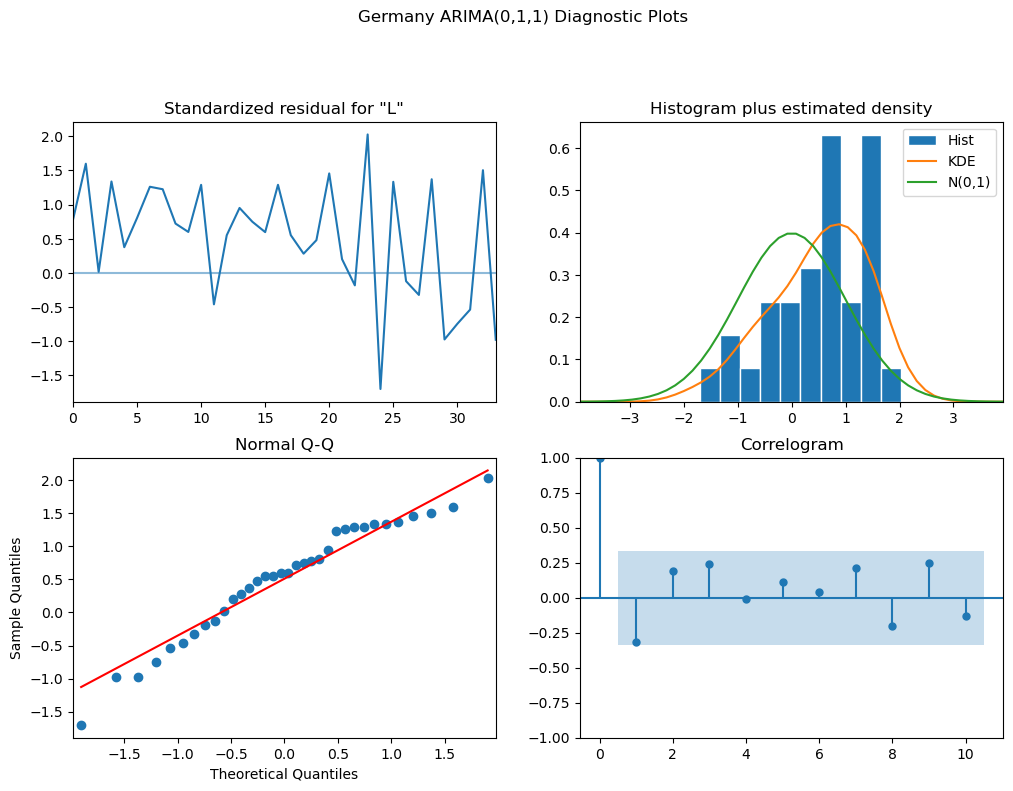

In [183]:
import matplotlib.pyplot as plt

final_germany_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle(
    "Germany ARIMA(0,1,1) Diagnostic Plots",
    y=1.02
)
plt.show()

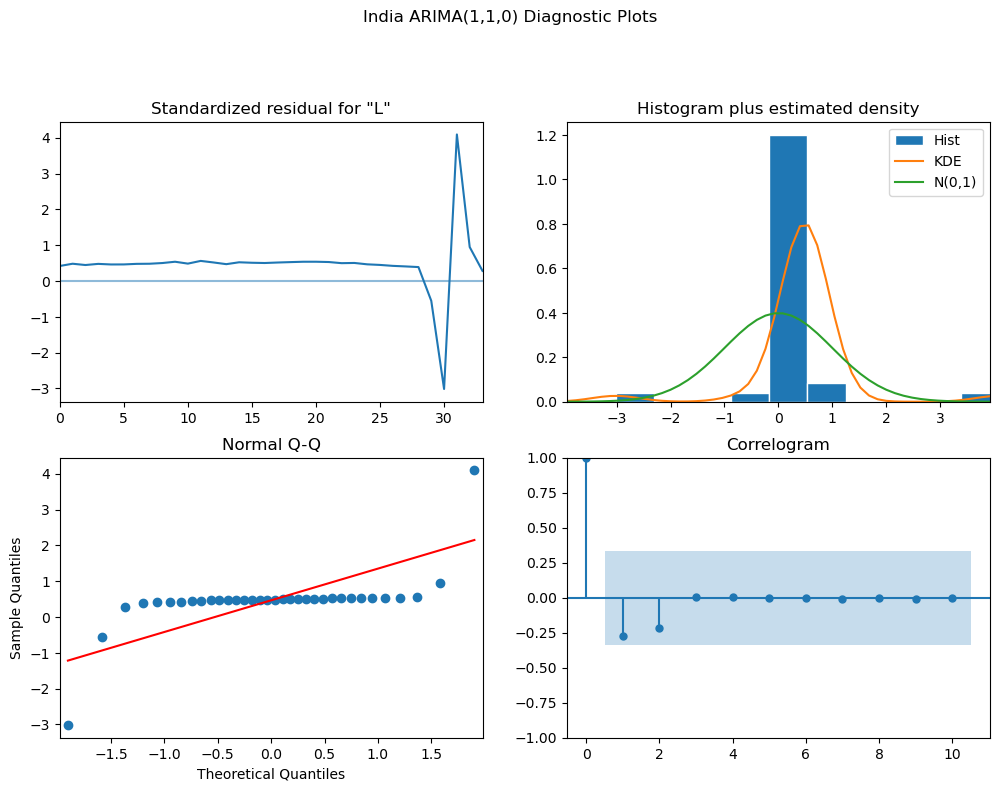

In [184]:
final_india_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle(
    "India ARIMA(1,1,0) Diagnostic Plots",
    y=1.02
)
plt.show()

In [185]:
from statsmodels.stats.diagnostic import acorr_ljungbox

germany_lb = acorr_ljungbox(
    final_germany_fit.resid,
    lags=[5],
    return_df=True
)

print("Germany Ljung-Box test")
display(germany_lb)

Germany Ljung-Box test


,lb_stat,lb_pvalue
5,0.002207,1.0


In [186]:
india_lb = acorr_ljungbox(
    final_india_fit.resid,
    lags=[5],
    return_df=True
)

print("India Ljung-Box test")
display(india_lb)

India Ljung-Box test


,lb_stat,lb_pvalue
5,0.002168,1.0


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [188]:
print("Germany train:")
print(germany_train.tail())

print("\nGermany test:")
print(germany_test)

print("\nIndia train:")
print(india_train.tail())

print("\nIndia test:")
print(india_test)

Germany train:
    Year  Life_Expectancy
23  2013        80.490244
24  2014        81.090244
25  2015        80.641463
26  2016        80.990244
27  2017        80.992683

Germany test:
    Year  Life_Expectancy  Naive_Forecast
28  2018        80.892683       80.992683
29  2019        81.292683       80.992683
30  2020        81.041463       80.992683
31  2021        80.790244       80.992683
32  2022        80.608049       80.992683
33  2023        81.041463       80.992683
34  2024        80.792683       80.992683

India train:
    Year  Life_Expectancy
23  2013           68.499
24  2014           68.932
25  2015           69.326
26  2016           69.709
27  2017           70.068

India test:
    Year  Life_Expectancy  Naive_Forecast
28  2018           70.415          70.068
29  2019           70.746          70.068
30  2020           70.156          70.068
31  2021           67.282          70.068
32  2022           71.698          70.068
33  2023           72.003          70.068
3

In [189]:
germany_ets = ExponentialSmoothing(
    germany_train["Life_Expectancy"],
    trend="add",
    damped_trend=True,
    seasonal=None
).fit()

germany_ets_pred = germany_ets.forecast(
    steps=len(germany_test)
)

print("Germany ETS predictions:")
print(germany_ets_pred)

Germany ETS predictions:
28    81.344816
29    81.490264
30    81.631625
31    81.769011
32    81.902536
33    82.032308
34    82.158432
dtype: float64


In [190]:
germany_ets_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_ets_pred
)

germany_ets_rmse = np.sqrt(
    mean_squared_error(
        germany_test["Life_Expectancy"],
        germany_ets_pred
    )
)

print("Germany ETS")
print(f"MAE  : {germany_ets_mae:.4f}")
print(f"RMSE : {germany_ets_rmse:.4f}")

Germany ETS
MAE  : 0.8385
RMSE : 0.9314


In [191]:
india_ets = ExponentialSmoothing(
    india_train["Life_Expectancy"],
    trend="add",
    damped_trend=True,
    seasonal=None
).fit()

india_ets_pred = india_ets.forecast(
    steps=len(india_test)
)

print("India ETS predictions:")
print(india_ets_pred)

India ETS predictions:
28    70.438048
29    70.799512
30    71.159169
31    71.517028
32    71.873097
33    72.227386
34    72.579904
dtype: float64


In [192]:
india_ets_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_ets_pred
)

india_ets_rmse = np.sqrt(
    mean_squared_error(
        india_test["Life_Expectancy"],
        india_ets_pred
    )
)

print("India ETS")
print(f"MAE  : {india_ets_mae:.4f}")
print(f"RMSE : {india_ets_rmse:.4f}")

India ETS
MAE  : 0.8656
RMSE : 1.6538


In [193]:
final_comparison = pd.DataFrame({
    "Country": [
        "Germany",
        "Germany",
        "Germany",
        "Germany",
        "Germany",
        "India",
        "India",
        "India",
        "India",
        "India"
    ],
    
    "Model": [
        "Naive",
        "Linear Trend",
        "Holt",
        "ARIMA(0,1,1)",
        "ETS Damped Trend",
        "Naive",
        "Linear Trend",
        "Holt",
        "ARIMA(1,1,0)",
        "ETS Damped Trend"
    ],
    
    "MAE": [
        0.183519,
        1.529296,
        0.668192,
        0.1821,
        germany_ets_mae,
        1.375857,
        1.226341,
        0.890374,
        0.825283,
        india_ets_mae
    ],
    
    "RMSE": [
        0.218333,
        1.633075,
        0.771547,
        0.2154,
        germany_ets_rmse,
        1.666761,
        1.875490,
        1.665916,
        1.633368,
        india_ets_rmse
    ]
})

final_comparison

,Country,Model,MAE,RMSE
0,Germany,Naive,0.183519,0.218333
1,Germany,Linear Trend,1.529296,1.633075
2,Germany,Holt,0.668192,0.771547
3,Germany,"ARIMA(0,1,1)",0.182100,0.215400
4,Germany,ETS Damped Trend,0.838532,0.931395
5,India,Naive,1.375857,1.666761
6,India,Linear Trend,1.226341,1.875490
7,India,Holt,0.890374,1.665916
8,India,"ARIMA(1,1,0)",0.825283,1.633368
9,India,ETS Damped Trend,0.865592,1.653791


In [194]:
germany_results = final_comparison[
    final_comparison["Country"] == "Germany"
].sort_values("MAE")

print("🇩🇪 Germany models ranked by MAE:")
display(germany_results)

🇩🇪 Germany models ranked by MAE:


,Country,Model,MAE,RMSE
3,Germany,"ARIMA(0,1,1)",0.182100,0.215400
0,Germany,Naive,0.183519,0.218333
2,Germany,Holt,0.668192,0.771547
4,Germany,ETS Damped Trend,0.838532,0.931395
1,Germany,Linear Trend,1.529296,1.633075


In [195]:
india_results = final_comparison[
    final_comparison["Country"] == "India"
].sort_values("MAE")

print("🇮🇳 India models ranked by MAE:")
display(india_results)

🇮🇳 India models ranked by MAE:


,Country,Model,MAE,RMSE
8,India,"ARIMA(1,1,0)",0.825283,1.633368
9,India,ETS Damped Trend,0.865592,1.653791
7,India,Holt,0.890374,1.665916
6,India,Linear Trend,1.226341,1.875490
5,India,Naive,1.375857,1.666761


In [196]:
import pandas as pd

final_model_comparison = pd.DataFrame({
    "Country": [
        "Germany", "Germany", "Germany", "Germany", "Germany",
        "India", "India", "India", "India", "India"
    ],
    "Model": [
        "ARIMA(0,1,1)",
        "Naive",
        "Holt",
        "ETS Damped Trend",
        "Linear Trend",
        "ARIMA(1,1,0)",
        "ETS Damped Trend",
        "Holt",
        "Linear Trend",
        "Naive"
    ],
    "MAE": [
        0.182100,
        0.183519,
        0.668192,
        0.838532,
        1.529296,
        0.825283,
        0.865592,
        0.890374,
        1.226341,
        1.375857
    ],
    "RMSE": [
        0.215400,
        0.218333,
        0.771547,
        0.931395,
        1.633075,
        1.633368,
        1.653791,
        1.665916,
        1.875490,
        1.666761
    ]
})

final_model_comparison

,Country,Model,MAE,RMSE
0,Germany,"ARIMA(0,1,1)",0.182100,0.215400
1,Germany,Naive,0.183519,0.218333
2,Germany,Holt,0.668192,0.771547
3,Germany,ETS Damped Trend,0.838532,0.931395
4,Germany,Linear Trend,1.529296,1.633075
5,India,"ARIMA(1,1,0)",0.825283,1.633368
6,India,ETS Damped Trend,0.865592,1.653791
7,India,Holt,0.890374,1.665916
8,India,Linear Trend,1.226341,1.875490
9,India,Naive,1.375857,1.666761


In [197]:
final_model_comparison.sort_values(
    ["Country", "MAE"]
)

,Country,Model,MAE,RMSE
0,Germany,"ARIMA(0,1,1)",0.182100,0.215400
1,Germany,Naive,0.183519,0.218333
2,Germany,Holt,0.668192,0.771547
3,Germany,ETS Damped Trend,0.838532,0.931395
4,Germany,Linear Trend,1.529296,1.633075
5,India,"ARIMA(1,1,0)",0.825283,1.633368
6,India,ETS Damped Trend,0.865592,1.653791
7,India,Holt,0.890374,1.665916
8,India,Linear Trend,1.226341,1.875490
9,India,Naive,1.375857,1.666761


In [198]:
# Show variables currently available in the notebook
%whos

Variable                      Type                         Data/Info
--------------------------------------------------------------------
ARIMA                         type                         <class 'statsmodels.tsa.arima.model.ARIMA'>
ExponentialSmoothing          type                         <class 'statsmodels.tsa.h<...>el.ExponentialSmoothing'>
Holt                          type                         <class 'statsmodels.tsa.holtwinters.model.Holt'>
LinearRegression              ABCMeta                      <class 'sklearn.linear_mo<...>._base.LinearRegression'>
X                             DataFrame                        Year\n0   1990\n1   1<...>\n\n[70 rows x 1 columns]
X_germany                     DataFrame                        Year\n0   1990\n1   1<...> 2022\n33  2023\n34  2024
X_germany_1                   DataFrame                        Physician_Density  Ho<...>07  \n34      10.706732  
X_germany_1b                  DataFrame                        Year  Physici

In [199]:
final_germany_model = ARIMA(
    germany_forecast["Life_Expectancy"],
    order=(0, 1, 1)
)

final_germany_fit = final_germany_model.fit()

In [200]:
final_india_model = ARIMA(
    india_forecast["Life_Expectancy"],
    order=(1, 1, 0)
)

final_india_fit = final_india_model.fit()

In [201]:
from statsmodels.tsa.arima.model import ARIMA

# ============================================
# FINAL GERMANY ARIMA MODEL
# ============================================

final_germany_model = ARIMA(
    germany_forecast["Life_Expectancy"],
    order=(0, 1, 1)
)

final_germany_fit = final_germany_model.fit()

print("Final Germany Model: ARIMA(0,1,1)")
print("--------------------------------")
print(final_germany_fit.summary())

Final Germany Model: ARIMA(0,1,1)
--------------------------------
                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  -7.146
Date:                Wed, 19 Aug 2026   AIC                             18.292
Time:                        17:01:22   BIC                             21.344
Sample:                             0   HQIC                            19.333
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0974      0.179      0.543      0.587      -0.254       0.449
sigma2         0.0891      0.032      2.758      0.006       0.0

In [202]:
# ============================================
# FINAL INDIA ARIMA MODEL
# ============================================

final_india_model = ARIMA(
    india_forecast["Life_Expectancy"],
    order=(1, 1, 0)
)

final_india_fit = final_india_model.fit()

print("Final India Model: ARIMA(1,1,0)")
print("-------------------------------")
print(final_india_fit.summary())

Final India Model: ARIMA(1,1,0)
-------------------------------
                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -47.574
Date:                Wed, 19 Aug 2026   AIC                             99.148
Time:                        17:01:22   BIC                            102.200
Sample:                             0   HQIC                           100.189
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1412      0.119     -1.182      0.237      -0.375       0.093
sigma2         0.9608      0.163      5.903      0.000       0.642 

In [203]:
print("Germany final model:", type(final_germany_fit))
print("India final model:", type(final_india_fit))

Germany final model: <class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>
India final model: <class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>


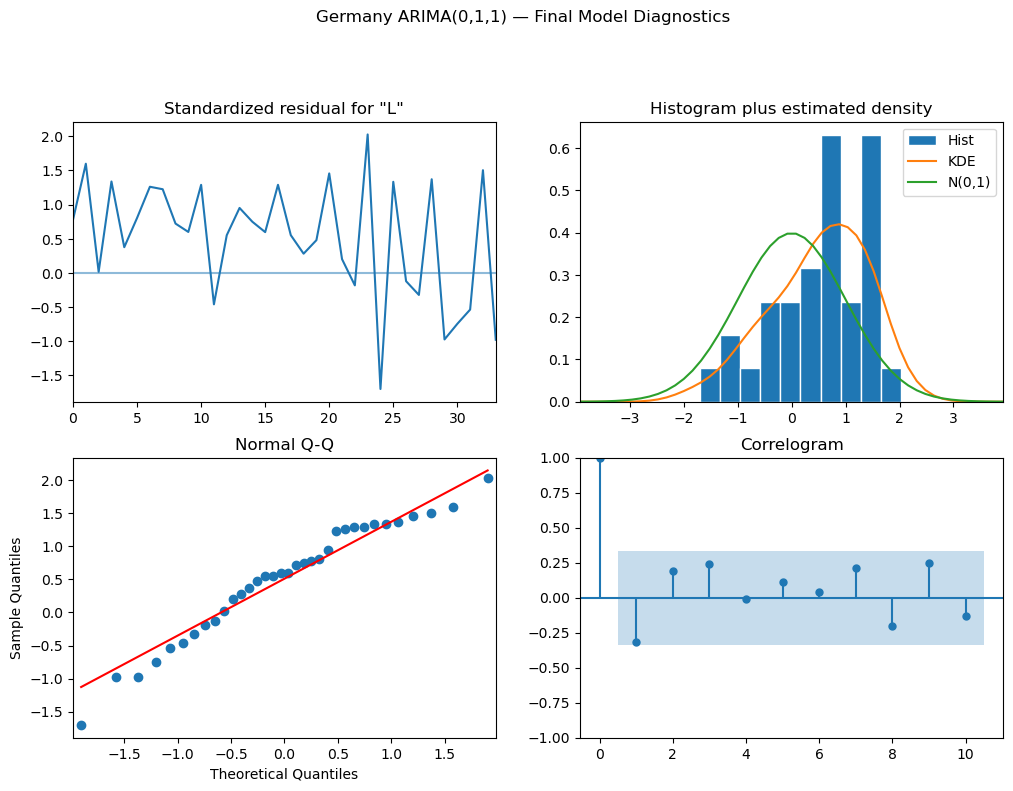

In [204]:
import matplotlib.pyplot as plt

final_germany_fit.plot_diagnostics(figsize=(12, 8))

plt.suptitle(
    "Germany ARIMA(0,1,1) — Final Model Diagnostics",
    y=1.02
)

plt.show()

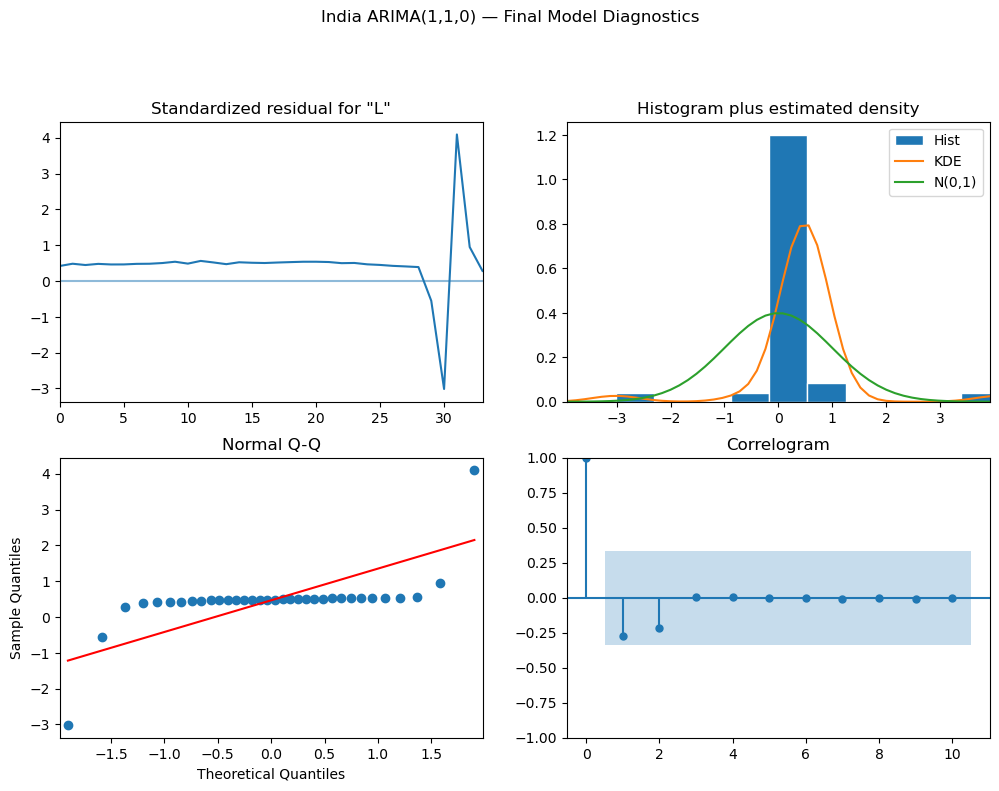

In [205]:
final_india_fit.plot_diagnostics(figsize=(12, 8))

plt.suptitle(
    "India ARIMA(1,1,0) — Final Model Diagnostics",
    y=1.02
)

plt.show()

In [206]:
# ============================================
# GERMANY: 2025–2050 FORECAST
# ============================================

germany_2050_result = final_germany_fit.get_forecast(
    steps=26
)

germany_2050_mean = germany_2050_result.predicted_mean
germany_2050_ci = germany_2050_result.conf_int()

germany_2050_df = pd.DataFrame({
    "Year": range(2025, 2051),
    "Forecast": germany_2050_mean.values,
    "Lower_CI": germany_2050_ci.iloc[:, 0].values,
    "Upper_CI": germany_2050_ci.iloc[:, 1].values
})

germany_2050_df

,Year,Forecast,Lower_CI,Upper_CI
0,2025,80.764177,80.179093,81.349261
1,2026,80.764177,79.895494,81.632860
2,2027,80.764177,79.683946,81.844408
3,2028,80.764177,79.507520,82.020834
4,2029,80.764177,79.352981,82.175373
5,2030,80.764177,79.213770,82.314584
6,2031,80.764177,79.086068,82.442286
7,2032,80.764177,78.967420,82.560934
8,2033,80.764177,78.856135,82.672219
9,2034,80.764177,78.750993,82.777361


In [207]:
# ============================================
# INDIA: 2025–2050 FORECAST
# ============================================

india_2050_result = final_india_fit.get_forecast(
    steps=26
)

india_2050_mean = india_2050_result.predicted_mean
india_2050_ci = india_2050_result.conf_int()

india_2050_df = pd.DataFrame({
    "Year": range(2025, 2051),
    "Forecast": india_2050_mean.values,
    "Lower_CI": india_2050_ci.iloc[:, 0].values,
    "Upper_CI": india_2050_ci.iloc[:, 1].values
})

india_2050_df

,Year,Forecast,Lower_CI,Upper_CI
0,2025,72.202248,70.281116,74.123379
1,2026,72.206872,69.674485,74.739258
2,2027,72.206219,69.162697,75.249740
3,2028,72.206311,68.728546,75.684075
4,2029,72.206298,68.342461,76.070135
5,2030,72.206300,67.991651,76.420949
6,2031,72.206300,67.667870,76.744729
7,2032,72.206300,67.365699,77.046901
8,2033,72.206300,67.081313,77.331287
9,2034,72.206300,66.811898,77.600701


In [208]:
print("Germany 2050 forecast:")
print(germany_2050_df[germany_2050_df["Year"] == 2050])

print("\nIndia 2050 forecast:")
print(india_2050_df[india_2050_df["Year"] == 2050])

Germany 2050 forecast:
    Year   Forecast   Lower_CI   Upper_CI
25  2050  80.764177  77.500818  84.027536

India 2050 forecast:
    Year  Forecast   Lower_CI   Upper_CI
25  2050   72.2063  63.578163  80.834436


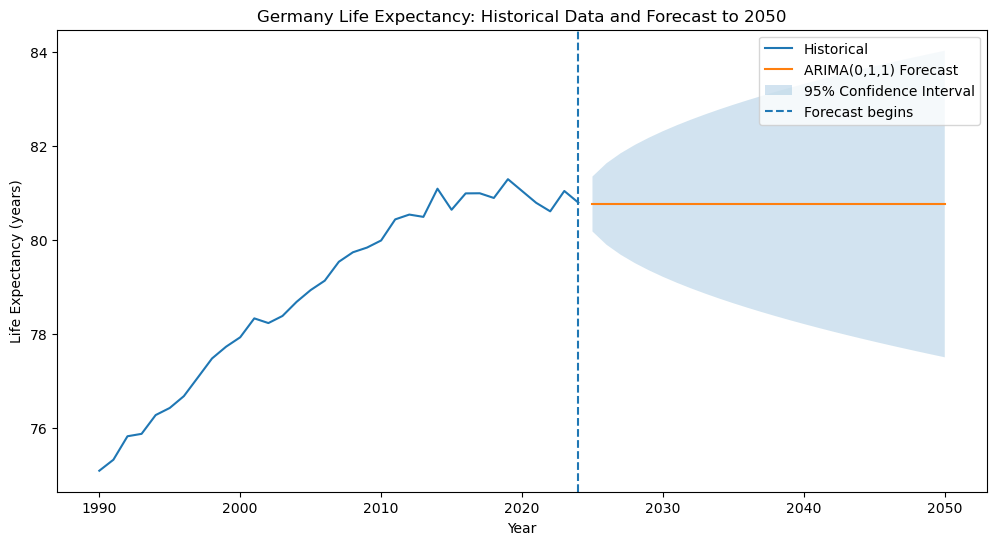

In [209]:
plt.figure(figsize=(12, 6))

# Historical data
plt.plot(
    germany_forecast["Year"],
    germany_forecast["Life_Expectancy"],
    label="Historical"
)

# Forecast
plt.plot(
    germany_2050_df["Year"],
    germany_2050_df["Forecast"],
    label="ARIMA(0,1,1) Forecast"
)

# Confidence interval
plt.fill_between(
    germany_2050_df["Year"],
    germany_2050_df["Lower_CI"],
    germany_2050_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    x=2024,
    linestyle="--",
    label="Forecast begins"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "Germany Life Expectancy: Historical Data and Forecast to 2050"
)

plt.legend()
plt.show()

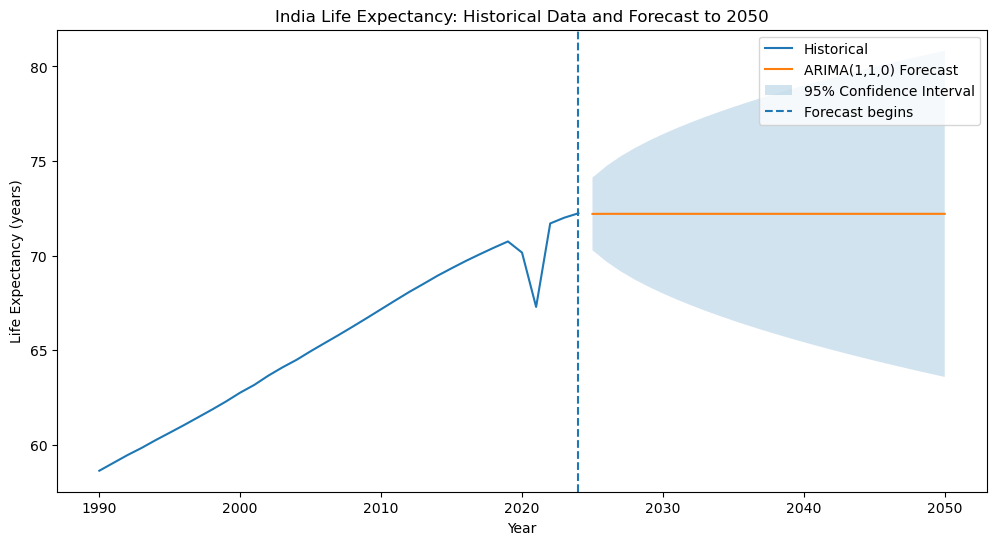

In [210]:
plt.figure(figsize=(12, 6))

# Historical data
plt.plot(
    india_forecast["Year"],
    india_forecast["Life_Expectancy"],
    label="Historical"
)

# Forecast
plt.plot(
    india_2050_df["Year"],
    india_2050_df["Forecast"],
    label="ARIMA(1,1,0) Forecast"
)

# Confidence interval
plt.fill_between(
    india_2050_df["Year"],
    india_2050_df["Lower_CI"],
    india_2050_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    x=2024,
    linestyle="--",
    label="Forecast begins"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "India Life Expectancy: Historical Data and Forecast to 2050"
)

plt.legend()
plt.show()

In [211]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

In [212]:
# Final Germany ETS Damped Trend Model

germany_ets_model = ExponentialSmoothing(
    germany_forecast["Life_Expectancy"],
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
)

germany_ets_fit = germany_ets_model.fit()

print(germany_ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:          Life_Expectancy   No. Observations:                   35
Model:             ExponentialSmoothing   SSE                              1.445
Optimized:                         True   AIC                           -101.558
Trend:                         Additive   BIC                            -93.781
Seasonal:                          None   AICC                           -97.410
Seasonal Periods:                  None   Date:                 Wed, 19 Aug 2026
Box-Cox:                          False   Time:                         17:01:32
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.4066016                alpha                 True
smoothing_trend            0.40532

In [213]:
germany_ets_forecast = germany_ets_fit.forecast(26)

germany_ets_2050 = pd.DataFrame({
    "Year": range(2025, 2051),
    "Forecast": germany_ets_forecast.values
})

print(germany_ets_2050)

    Year   Forecast
0   2025  80.770639
1   2026  80.729603
2   2027  80.690521
3   2028  80.653301
4   2029  80.617853
5   2030  80.584094
6   2031  80.551942
7   2032  80.521322
8   2033  80.492160
9   2034  80.464387
10  2035  80.437937
11  2036  80.412747
12  2037  80.388757
13  2038  80.365909
14  2039  80.344149
15  2040  80.323426
16  2041  80.303690
17  2042  80.284894
18  2043  80.266993
19  2044  80.249944
20  2045  80.233708
21  2046  80.218245
22  2047  80.203518
23  2048  80.189493
24  2049  80.176136
25  2050  80.163415


In [214]:
# Final India ETS Damped Trend Model

india_ets_model = ExponentialSmoothing(
    india_forecast["Life_Expectancy"],
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
)

india_ets_fit = india_ets_model.fit()

print(india_ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:          Life_Expectancy   No. Observations:                   35
Model:             ExponentialSmoothing   SSE                             16.128
Optimized:                         True   AIC                            -17.117
Trend:                         Additive   BIC                             -9.340
Seasonal:                          None   AICC                           -12.969
Seasonal Periods:                  None   Date:                 Wed, 19 Aug 2026
Box-Cox:                          False   Time:                         17:01:32
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level           1.4901e-08                alpha                 True
smoothing_trend           1.4374e-

In [215]:
india_ets_forecast = india_ets_fit.forecast(26)

india_ets_2050 = pd.DataFrame({
    "Year": range(2025, 2051),
    "Forecast": india_ets_forecast.values
})

print(india_ets_2050)

    Year   Forecast
0   2025  72.162763
1   2026  72.469115
2   2027  72.771287
3   2028  73.069335
4   2029  73.363315
5   2030  73.653283
6   2031  73.939294
7   2032  74.221402
8   2033  74.499660
9   2034  74.774120
10  2035  75.044835
11  2036  75.311855
12  2037  75.575231
13  2038  75.835012
14  2039  76.091249
15  2040  76.343988
16  2041  76.593279
17  2042  76.839167
18  2043  77.081699
19  2044  77.320922
20  2045  77.556880
21  2046  77.789618
22  2047  78.019179
23  2048  78.245608
24  2049  78.468946
25  2050  78.689237


In [216]:
print("GERMANY 2050:")
print(germany_ets_2050.tail(1))

print("\nINDIA 2050:")
print(india_ets_2050.tail(1))

GERMANY 2050:
    Year   Forecast
25  2050  80.163415

INDIA 2050:
    Year   Forecast
25  2050  78.689237


In [217]:
access_indicators = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Hospital_Density",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

In [218]:
access_indicators = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Hospital_Density",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

In [219]:
health_outcomes = [
    "Infant_Mortality",
    "Cardiovascular_Deaths_Rate",
    "Chronic_Respiratory_Deaths_Rate",
    "Diabetes_Deaths_Rate",
    "Neoplasms_Deaths_Rate",
    "NCD_Mortality_Probability",
    "Diabetes_Prevalence",
    "Obesity_Prevalence"
]

In [220]:
socioeconomic = [
    "GDP_per_Capita",
    "Urban_Population",
    "Total_Population",
    "Birth_Rate"
]

In [221]:
target = "Life_Expectancy"

# Healthcare Indicator Analysis

In [223]:
# Create country datasets containing ALL indicators

germany_indicators = (
    df[df["Country"] == "Germany"]
    .sort_values("Year")
    .reset_index(drop=True)
    .copy()
)

india_indicators = (
    df[df["Country"] == "India"]
    .sort_values("Year")
    .reset_index(drop=True)
    .copy()
)

print("Germany:", germany_indicators.shape)
print("India:", india_indicators.shape)

Germany: (35, 21)
India: (35, 21)


In [224]:
print("GERMANY COLUMNS:")
print(germany_indicators.columns.tolist())

print("\nINDIA COLUMNS:")
print(india_indicators.columns.tolist())

GERMANY COLUMNS:
['Year', 'Country', 'Infant_Mortality', 'GDP_per_Capita', 'Urban_Population', 'Total_Population', 'Obesity_Prevalence', 'Cardiovascular_Deaths_Rate', 'Chronic_Respiratory_Deaths_Rate', 'Diabetes_Deaths_Rate', 'Neoplasms_Deaths_Rate', 'UHC_Coverage_Index', 'NCD_Mortality_Probability', 'Diabetes_Prevalence', 'Hospital_Density', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Birth_Rate', 'Health_Expenditure_y', 'Out_of_Pocket']

INDIA COLUMNS:
['Year', 'Country', 'Infant_Mortality', 'GDP_per_Capita', 'Urban_Population', 'Total_Population', 'Obesity_Prevalence', 'Cardiovascular_Deaths_Rate', 'Chronic_Respiratory_Deaths_Rate', 'Diabetes_Deaths_Rate', 'Neoplasms_Deaths_Rate', 'UHC_Coverage_Index', 'NCD_Mortality_Probability', 'Diabetes_Prevalence', 'Hospital_Density', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Birth_Rate', 'Health_Expenditure_y', 'Out_of_Pocket']


In [225]:
indicator_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Hospital_Density",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index",
    "GDP_per_Capita",
    "Infant_Mortality",
    "Diabetes_Prevalence",
    "NCD_Mortality_Probability",
    "Obesity_Prevalence"
]

germany_indicator_corr = (
    germany_indicators[indicator_columns]
    .corr()["Life_Expectancy"]
    .sort_values(ascending=False)
)

india_indicator_corr = (
    india_indicators[indicator_columns]
    .corr()["Life_Expectancy"]
    .sort_values(ascending=False)
)

print("🇩🇪 GERMANY")
display(germany_indicator_corr)

print("\n🇮🇳 INDIA")
display(india_indicator_corr)

🇩🇪 GERMANY


Life_Expectancy              1.000000
Obesity_Prevalence           0.979516
Physician_Density            0.943892
Health_Expenditure_y         0.899042
GDP_per_Capita               0.875514
Diabetes_Prevalence          0.775060
UHC_Coverage_Index           0.442492
NCD_Mortality_Probability   -0.428122
Out_of_Pocket               -0.646576
Infant_Mortality            -0.970118
Hospital_Beds_Per_1000      -0.975521
Hospital_Density                  NaN
Name: Life_Expectancy, dtype: float64


🇮🇳 INDIA


Life_Expectancy              1.000000
Obesity_Prevalence           0.943509
GDP_per_Capita               0.914188
Diabetes_Prevalence          0.870771
UHC_Coverage_Index           0.526648
Hospital_Beds_Per_1000       0.366750
NCD_Mortality_Probability    0.257193
Health_Expenditure_y        -0.924560
Out_of_Pocket               -0.939909
Physician_Density           -0.945292
Infant_Mortality            -0.986055
Hospital_Density                  NaN
Name: Life_Expectancy, dtype: float64

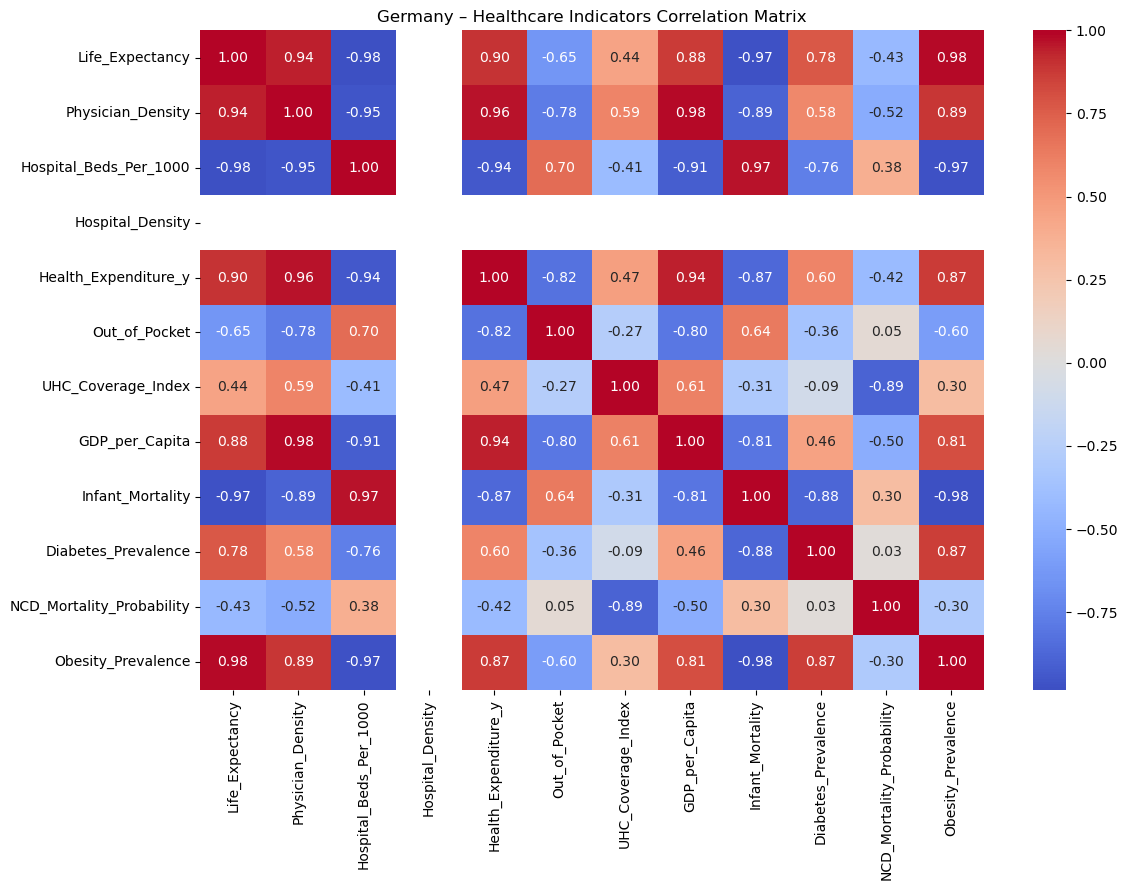

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

indicator_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Hospital_Density",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index",
    "GDP_per_Capita",
    "Infant_Mortality",
    "Diabetes_Prevalence",
    "NCD_Mortality_Probability",
    "Obesity_Prevalence"
]

germany_corr = germany_indicators[indicator_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    germany_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Germany – Healthcare Indicators Correlation Matrix")
plt.tight_layout()
plt.show()

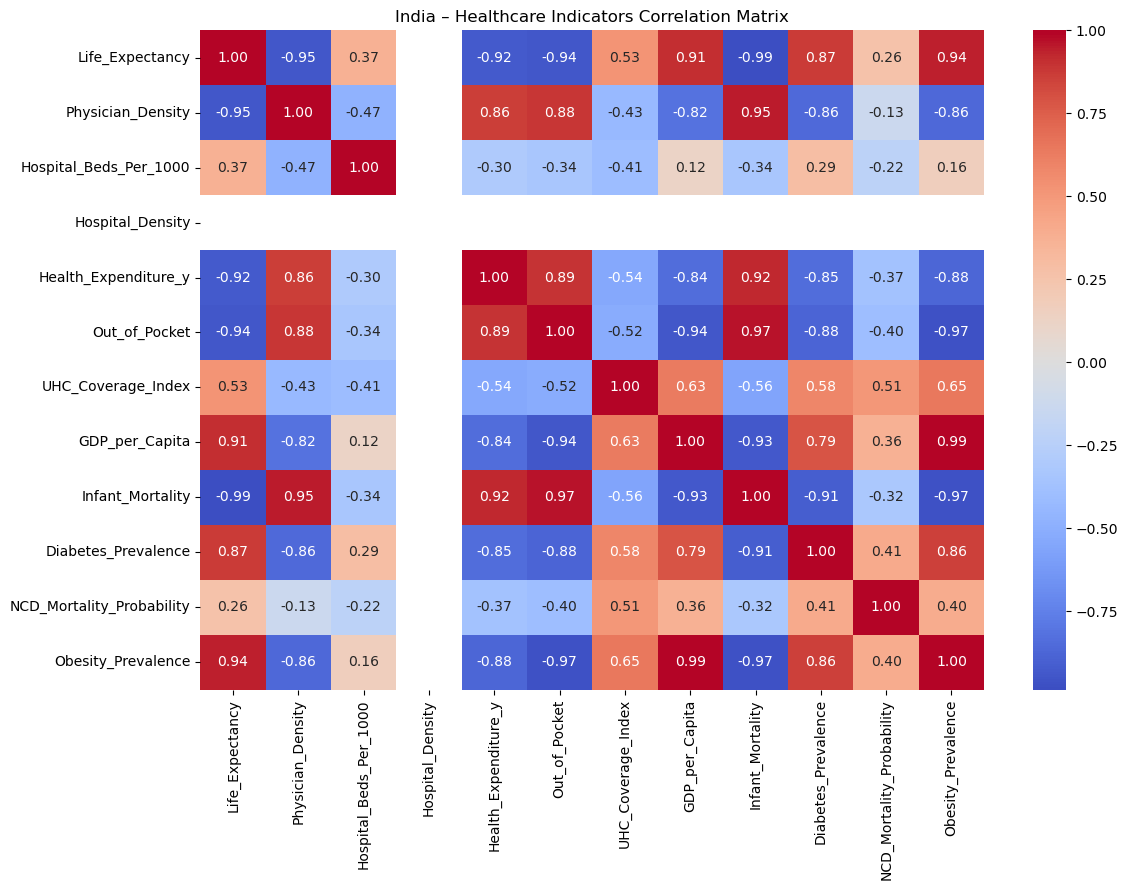

In [227]:
india_corr = india_indicators[indicator_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    india_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("India – Healthcare Indicators Correlation Matrix")
plt.tight_layout()
plt.show()

In [228]:
print("GERMANY – correlations with Life Expectancy")
print(
    germany_indicators[indicator_columns]
    .corr()["Life_Expectancy"]
    .drop("Life_Expectancy")
    .sort_values(key=abs, ascending=False)
)

print("\nINDIA – correlations with Life Expectancy")
print(
    india_indicators[indicator_columns]
    .corr()["Life_Expectancy"]
    .drop("Life_Expectancy")
    .sort_values(key=abs, ascending=False)
)

GERMANY – correlations with Life Expectancy
Obesity_Prevalence           0.979516
Hospital_Beds_Per_1000      -0.975521
Infant_Mortality            -0.970118
Physician_Density            0.943892
Health_Expenditure_y         0.899042
GDP_per_Capita               0.875514
Diabetes_Prevalence          0.775060
Out_of_Pocket               -0.646576
UHC_Coverage_Index           0.442492
NCD_Mortality_Probability   -0.428122
Hospital_Density                  NaN
Name: Life_Expectancy, dtype: float64

INDIA – correlations with Life Expectancy
Infant_Mortality            -0.986055
Physician_Density           -0.945292
Obesity_Prevalence           0.943509
Out_of_Pocket               -0.939909
Health_Expenditure_y        -0.924560
GDP_per_Capita               0.914188
Diabetes_Prevalence          0.870771
UHC_Coverage_Index           0.526648
Hospital_Beds_Per_1000       0.366750
NCD_Mortality_Probability    0.257193
Hospital_Density                  NaN
Name: Life_Expectancy, dtype: float64


In [229]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

vif_columns = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index",
    "GDP_per_Capita",
    "Diabetes_Prevalence",
    "NCD_Mortality_Probability",
    "Obesity_Prevalence"
]

def calculate_vif(data, columns):
    X = data[columns].copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif.sort_values("VIF", ascending=False)

print("GERMANY VIF")
display(calculate_vif(germany_indicators, vif_columns))

print("\nINDIA VIF")
display(calculate_vif(india_indicators, vif_columns))

GERMANY VIF


,Variable,VIF
4,UHC_Coverage_Index,13725.983005
1,Hospital_Beds_Per_1000,11812.699488
0,Physician_Density,11257.627318
8,Obesity_Prevalence,6547.170054
6,Diabetes_Prevalence,5464.585182
3,Out_of_Pocket,2938.184805
7,NCD_Mortality_Probability,2517.691259
2,Health_Expenditure_y,1523.393054
5,GDP_per_Capita,909.600443



INDIA VIF


,Variable,VIF
7,NCD_Mortality_Probability,2216.115936
8,Obesity_Prevalence,1038.159980
3,Out_of_Pocket,609.697267
5,GDP_per_Capita,566.989334
0,Physician_Density,426.340989
6,Diabetes_Prevalence,398.915517
2,Health_Expenditure_y,363.741491
4,UHC_Coverage_Index,146.112625
1,Hospital_Beds_Per_1000,87.117573


In [230]:
indicator_summary = pd.DataFrame({
    "Indicator": [
        "Physician Density",
        "Hospital Beds",
        "Health Expenditure",
        "Out-of-Pocket",
        "UHC Coverage",
        "GDP per Capita",
        "Infant Mortality",
        "Diabetes Prevalence",
        "NCD Mortality",
        "Obesity Prevalence"
    ],

    "Germany_Correlation": [
        germany_indicator_corr.get("Physician_Density"),
        germany_indicator_corr.get("Hospital_Beds_Per_1000"),
        germany_indicator_corr.get("Health_Expenditure_y"),
        germany_indicator_corr.get("Out_of_Pocket"),
        germany_indicator_corr.get("UHC_Coverage_Index"),
        germany_indicator_corr.get("GDP_per_Capita"),
        germany_indicator_corr.get("Infant_Mortality"),
        germany_indicator_corr.get("Diabetes_Prevalence"),
        germany_indicator_corr.get("NCD_Mortality_Probability"),
        germany_indicator_corr.get("Obesity_Prevalence")
    ],

    "India_Correlation": [
        india_indicator_corr.get("Physician_Density"),
        india_indicator_corr.get("Hospital_Beds_Per_1000"),
        india_indicator_corr.get("Health_Expenditure_y"),
        india_indicator_corr.get("Out_of_Pocket"),
        india_indicator_corr.get("UHC_Coverage_Index"),
        india_indicator_corr.get("GDP_per_Capita"),
        india_indicator_corr.get("Infant_Mortality"),
        india_indicator_corr.get("Diabetes_Prevalence"),
        india_indicator_corr.get("NCD_Mortality_Probability"),
        india_indicator_corr.get("Obesity_Prevalence")
    ]
})

indicator_summary

,Indicator,Germany_Correlation,India_Correlation
0,Physician Density,0.943892,-0.945292
1,Hospital Beds,-0.975521,0.366750
2,Health Expenditure,0.899042,-0.924560
3,Out-of-Pocket,-0.646576,-0.939909
4,UHC Coverage,0.442492,0.526648
5,GDP per Capita,0.875514,0.914188
6,Infant Mortality,-0.970118,-0.986055
7,Diabetes Prevalence,0.775060,0.870771
8,NCD Mortality,-0.428122,0.257193
9,Obesity Prevalence,0.979516,0.943509


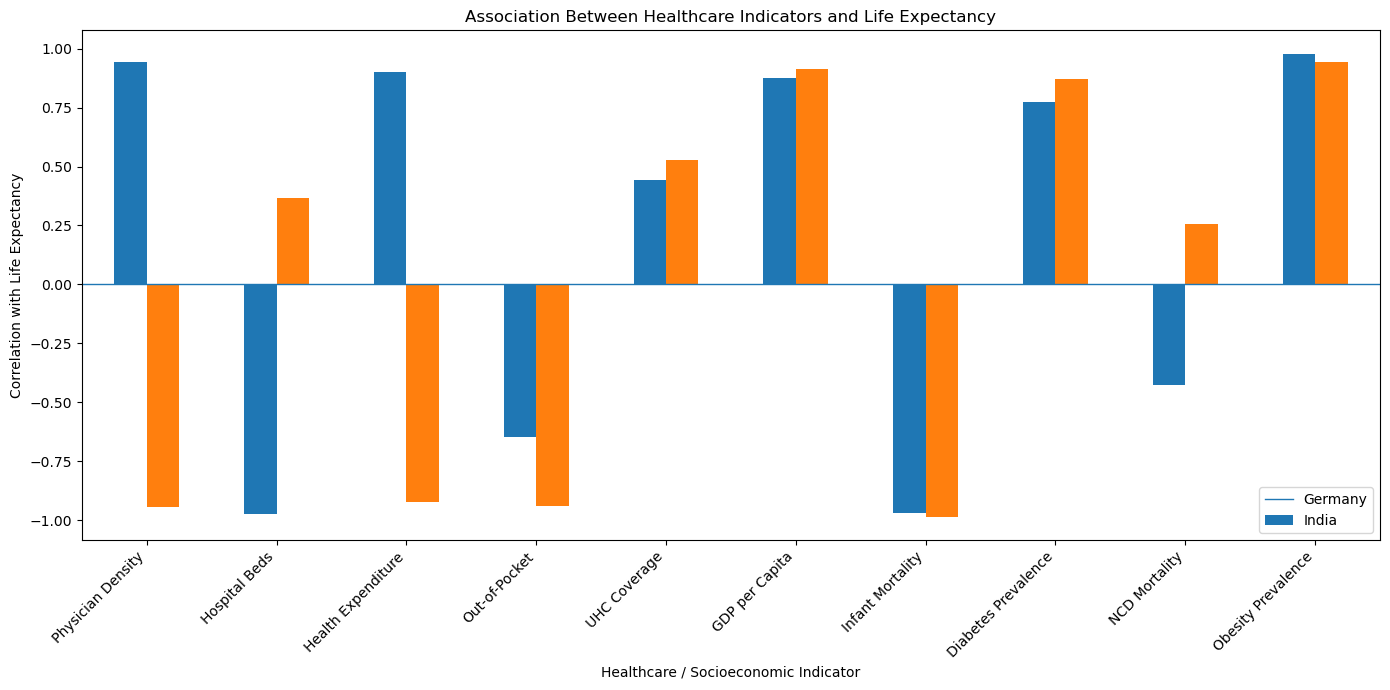

In [231]:
import matplotlib.pyplot as plt

plot_df = indicator_summary.set_index("Indicator")

plot_df.plot(
    kind="bar",
    figsize=(14,7)
)

plt.axhline(0, linewidth=1)
plt.ylabel("Correlation with Life Expectancy")
plt.xlabel("Healthcare / Socioeconomic Indicator")
plt.title("Association Between Healthcare Indicators and Life Expectancy")
plt.xticks(rotation=45, ha="right")
plt.legend(["Germany", "India"])
plt.tight_layout()
plt.show()

In [232]:
plt.savefig("indicator_correlations.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [233]:
# ============================================================
# CREATE COUNTRY-SPECIFIC HISTORICAL DATASETS
# ============================================================

germany_data = (
    df[df["Country"] == "Germany"]
    .sort_values("Year")
    .reset_index(drop=True)
)

india_data = (
    df[df["Country"] == "India"]
    .sort_values("Year")
    .reset_index(drop=True)
)

print("Germany:", germany_data.shape)
print("India:", india_data.shape)

print("\nGermany years:")
print(germany_data["Year"].min(), "to", germany_data["Year"].max())

print("\nIndia years:")
print(india_data["Year"].min(), "to", india_data["Year"].max())

Germany: (35, 21)
India: (35, 21)

Germany years:
1990 to 2024

India years:
1990 to 2024


In [234]:
indicator_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index",
    "GDP_per_Capita",
    "Infant_Mortality",
    "Diabetes_Prevalence",
    "NCD_Mortality_Probability",
    "Obesity_Prevalence"
]

print("Missing from Germany:")
print([col for col in indicator_columns if col not in germany_data.columns])

print("\nMissing from India:")
print([col for col in indicator_columns if col not in india_data.columns])

Missing from Germany:
[]

Missing from India:
[]


In [235]:
def calculate_differenced_correlations(df_country):

    diff_data = df_country[indicator_columns].copy()

    # Calculate year-to-year changes
    diff_data = diff_data.diff()

    # Remove first row because it has NaN after differencing
    diff_data = diff_data.dropna()

    # Correlation with change in Life Expectancy
    correlations = (
        diff_data
        .corr()["Life_Expectancy"]
        .sort_values(ascending=False)
    )

    return correlations

In [236]:
germany_diff_corr = calculate_differenced_correlations(germany_data)

india_diff_corr = calculate_differenced_correlations(india_data)

print("🇩🇪 GERMANY — DIFFERENCED CORRELATIONS")
display(germany_diff_corr)

print("\n🇮🇳 INDIA — DIFFERENCED CORRELATIONS")
display(india_diff_corr)

🇩🇪 GERMANY — DIFFERENCED CORRELATIONS


Life_Expectancy              1.000000
Obesity_Prevalence           0.368442
Out_of_Pocket                0.253125
Diabetes_Prevalence          0.203146
UHC_Coverage_Index           0.126829
Physician_Density            0.113003
GDP_per_Capita              -0.034424
Hospital_Beds_Per_1000      -0.132792
NCD_Mortality_Probability   -0.212599
Infant_Mortality            -0.342716
Health_Expenditure_y        -0.416553
Name: Life_Expectancy, dtype: float64


🇮🇳 INDIA — DIFFERENCED CORRELATIONS


Life_Expectancy              1.000000
Out_of_Pocket                0.182298
Physician_Density            0.132138
GDP_per_Capita               0.114059
Hospital_Beds_Per_1000       0.033748
Diabetes_Prevalence          0.016834
UHC_Coverage_Index           0.011760
Obesity_Prevalence          -0.002207
Health_Expenditure_y        -0.030342
Infant_Mortality            -0.033486
NCD_Mortality_Probability   -0.450951
Name: Life_Expectancy, dtype: float64

In [237]:
indicator_difference_comparison = pd.DataFrame({
    "Germany_Diff_Correlation": germany_diff_corr,
    "India_Diff_Correlation": india_diff_corr
})

indicator_difference_comparison

,Germany_Diff_Correlation,India_Diff_Correlation
Diabetes_Prevalence,0.203146,0.016834
GDP_per_Capita,-0.034424,0.114059
Health_Expenditure_y,-0.416553,-0.030342
Hospital_Beds_Per_1000,-0.132792,0.033748
Infant_Mortality,-0.342716,-0.033486
Life_Expectancy,1.000000,1.000000
NCD_Mortality_Probability,-0.212599,-0.450951
Obesity_Prevalence,0.368442,-0.002207
Out_of_Pocket,0.253125,0.182298
Physician_Density,0.113003,0.132138


In [238]:
indicator_difference_comparison["Germany_Absolute"] = (
    indicator_difference_comparison["Germany_Diff_Correlation"].abs()
)

indicator_difference_comparison["India_Absolute"] = (
    indicator_difference_comparison["India_Diff_Correlation"].abs()
)

indicator_difference_comparison

,Germany_Diff_Correlation,India_Diff_Correlation,Germany_Absolute,India_Absolute
Diabetes_Prevalence,0.203146,0.016834,0.203146,0.016834
GDP_per_Capita,-0.034424,0.114059,0.034424,0.114059
Health_Expenditure_y,-0.416553,-0.030342,0.416553,0.030342
Hospital_Beds_Per_1000,-0.132792,0.033748,0.132792,0.033748
Infant_Mortality,-0.342716,-0.033486,0.342716,0.033486
Life_Expectancy,1.000000,1.000000,1.000000,1.000000
NCD_Mortality_Probability,-0.212599,-0.450951,0.212599,0.450951
Obesity_Prevalence,0.368442,-0.002207,0.368442,0.002207
Out_of_Pocket,0.253125,0.182298,0.253125,0.182298
Physician_Density,0.113003,0.132138,0.113003,0.132138


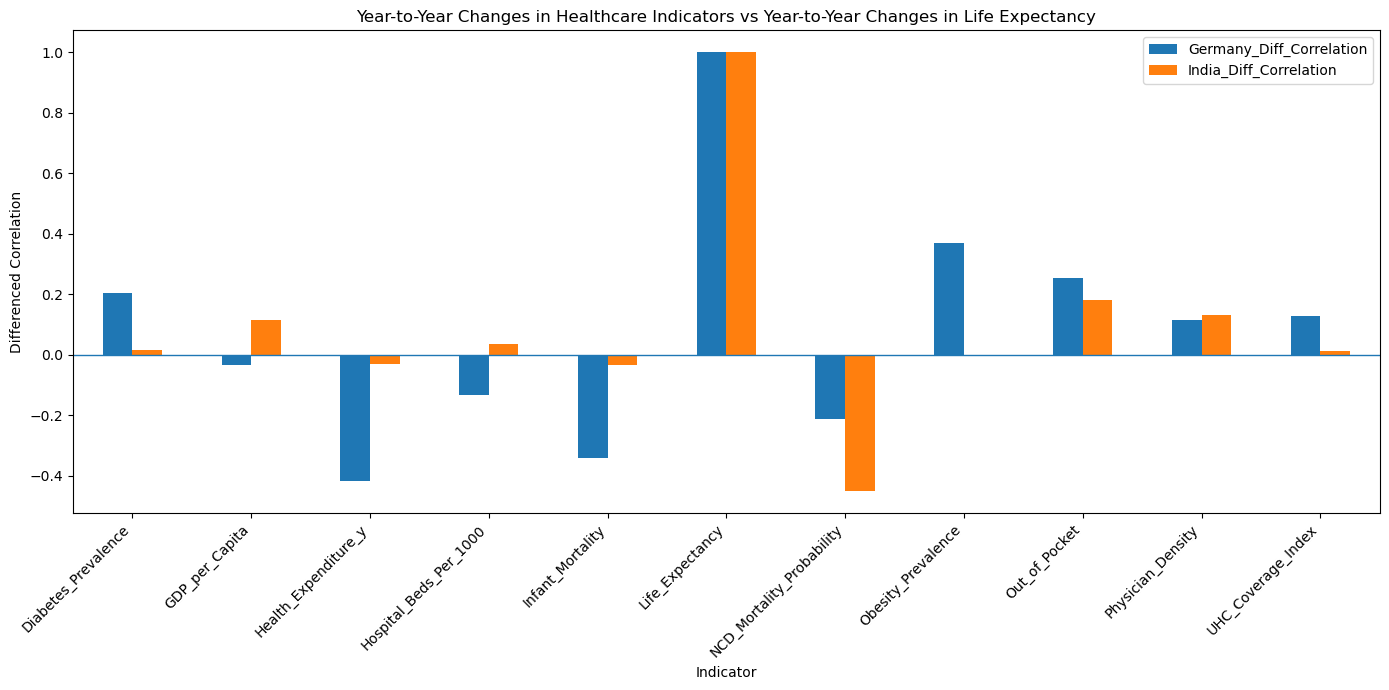

In [239]:
comparison_plot = indicator_difference_comparison[
    ["Germany_Diff_Correlation", "India_Diff_Correlation"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.axhline(0, linewidth=1)

plt.title(
    "Year-to-Year Changes in Healthcare Indicators vs "
    "Year-to-Year Changes in Life Expectancy"
)

plt.ylabel("Differenced Correlation")
plt.xlabel("Indicator")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [240]:
# ============================================================
# SCENARIO ASSUMPTIONS
# ============================================================

scenario_assumptions = {
    
    "Germany": {
        "Improved": {
            "Health_Expenditure_y": 1.0,
            "Out_of_Pocket": -1.0,
            "NCD_Mortality_Probability": -1.0
        },
        
        "Adverse": {
            "Health_Expenditure_y": -1.0,
            "Out_of_Pocket": 1.0,
            "NCD_Mortality_Probability": 1.0
        }
    },
    
    "India": {
        "Improved": {
            "Physician_Density": 1.0,
            "Out_of_Pocket": -1.0,
            "NCD_Mortality_Probability": -1.0
        },
        
        "Adverse": {
            "Physician_Density": -1.0,
            "Out_of_Pocket": 1.0,
            "NCD_Mortality_Probability": 1.0
        }
    }
}

scenario_assumptions

{'Germany': {'Improved': {'Health_Expenditure_y': 1.0,
   'Out_of_Pocket': -1.0,
   'NCD_Mortality_Probability': -1.0},
  'Adverse': {'Health_Expenditure_y': -1.0,
   'Out_of_Pocket': 1.0,
   'NCD_Mortality_Probability': 1.0}},
 'India': {'Improved': {'Physician_Density': 1.0,
   'Out_of_Pocket': -1.0,
   'NCD_Mortality_Probability': -1.0},
  'Adverse': {'Physician_Density': -1.0,
   'Out_of_Pocket': 1.0,
   'NCD_Mortality_Probability': 1.0}}}

In [241]:
from statsmodels.tsa.arima.model import ARIMA

# Germany
germany_series = (
    germany_data
    .set_index("Year")["Life_Expectancy"]
    .astype(float)
)

germany_arima = ARIMA(
    germany_series,
    order=(0, 1, 1)
).fit()


# India
india_series = (
    india_data
    .set_index("Year")["Life_Expectancy"]
    .astype(float)
)

india_arima = ARIMA(
    india_series,
    order=(1, 1, 0)
).fit()

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and w

In [242]:
forecast_years = 2050 - 2024

germany_arima_forecast = germany_arima.forecast(
    steps=forecast_years
)

india_arima_forecast = india_arima.forecast(
    steps=forecast_years
)

future_years = range(2025, 2051)

germany_baseline = pd.DataFrame({
    "Year": future_years,
    "Forecast": germany_arima_forecast.values
})

india_baseline = pd.DataFrame({
    "Year": future_years,
    "Forecast": india_arima_forecast.values
})

print("GERMANY")
display(germany_baseline.tail())

print("INDIA")
display(india_baseline.tail())

GERMANY


C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Year,Forecast
21,2046,80.764177
22,2047,80.764177
23,2048,80.764177
24,2049,80.764177
25,2050,80.764177


INDIA


,Year,Forecast
21,2046,72.2063
22,2047,72.2063
23,2048,72.2063
24,2049,72.2063
25,2050,72.2063


In [243]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np

In [244]:
germany_life = germany_forecast["Life_Expectancy"].dropna()

germany_ets_model = ExponentialSmoothing(
    germany_life,
    trend="add",
    damped_trend=True,
    seasonal=None
)

germany_ets_fit = germany_ets_model.fit(
    optimized=True
)

germany_ets_forecast = germany_ets_fit.forecast(
    steps=26
)

germany_ets_2050 = germany_ets_forecast.iloc[-1]

print("Germany ETS Damped Trend 2050:")
print(germany_ets_2050)

Germany ETS Damped Trend 2050:
80.16341520148933


In [245]:
india_life = india_forecast["Life_Expectancy"].dropna()

india_ets_model = ExponentialSmoothing(
    india_life,
    trend="add",
    damped_trend=True,
    seasonal=None
)

india_ets_fit = india_ets_model.fit(
    optimized=True
)

india_ets_forecast = india_ets_fit.forecast(
    steps=26
)

india_ets_2050 = india_ets_forecast.iloc[-1]

print("India ETS Damped Trend 2050:")
print(india_ets_2050)

India ETS Damped Trend 2050:
78.68923675184378


In [246]:
forecast_years = np.arange(2025, 2051)

germany_ets_df = pd.DataFrame({
    "Year": forecast_years,
    "Forecast": germany_ets_forecast.values
})

india_ets_df = pd.DataFrame({
    "Year": forecast_years,
    "Forecast": india_ets_forecast.values
})

print("🇩🇪 GERMANY ETS DAMPED TREND")
display(germany_ets_df)

print("\n🇮🇳 INDIA ETS DAMPED TREND")
display(india_ets_df)

🇩🇪 GERMANY ETS DAMPED TREND


,Year,Forecast
0,2025,80.770639
1,2026,80.729603
2,2027,80.690521
3,2028,80.653301
4,2029,80.617853
5,2030,80.584094
6,2031,80.551942
7,2032,80.521322
8,2033,80.492160
9,2034,80.464387



🇮🇳 INDIA ETS DAMPED TREND


,Year,Forecast
0,2025,72.162763
1,2026,72.469115
2,2027,72.771287
3,2028,73.069335
4,2029,73.363315
5,2030,73.653283
6,2031,73.939294
7,2032,74.221402
8,2033,74.499660
9,2034,74.774120


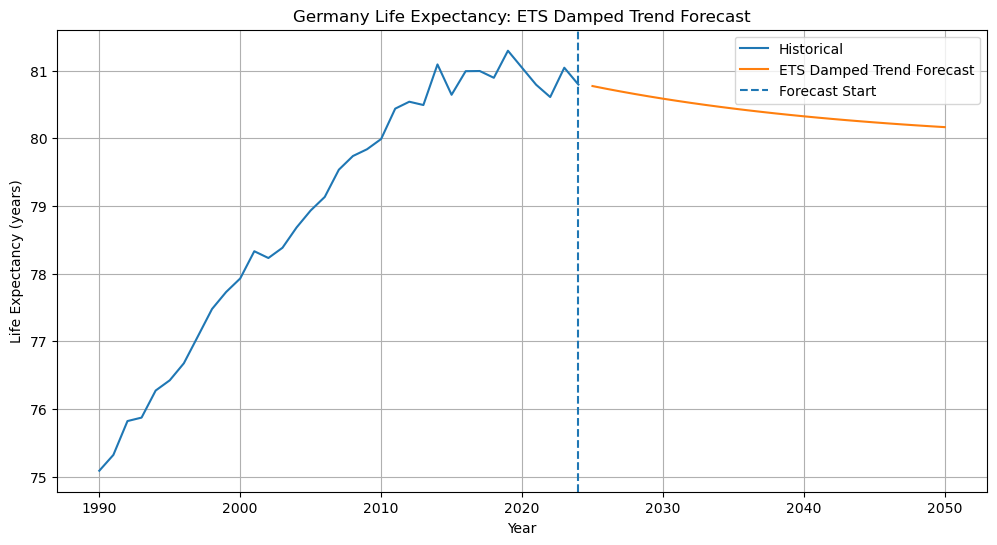

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    germany_forecast["Year"],
    germany_forecast["Life_Expectancy"],
    label="Historical"
)

plt.plot(
    germany_ets_df["Year"],
    germany_ets_df["Forecast"],
    label="ETS Damped Trend Forecast"
)

plt.axvline(
    x=2024,
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("Germany Life Expectancy: ETS Damped Trend Forecast")
plt.legend()
plt.grid(True)

plt.show()

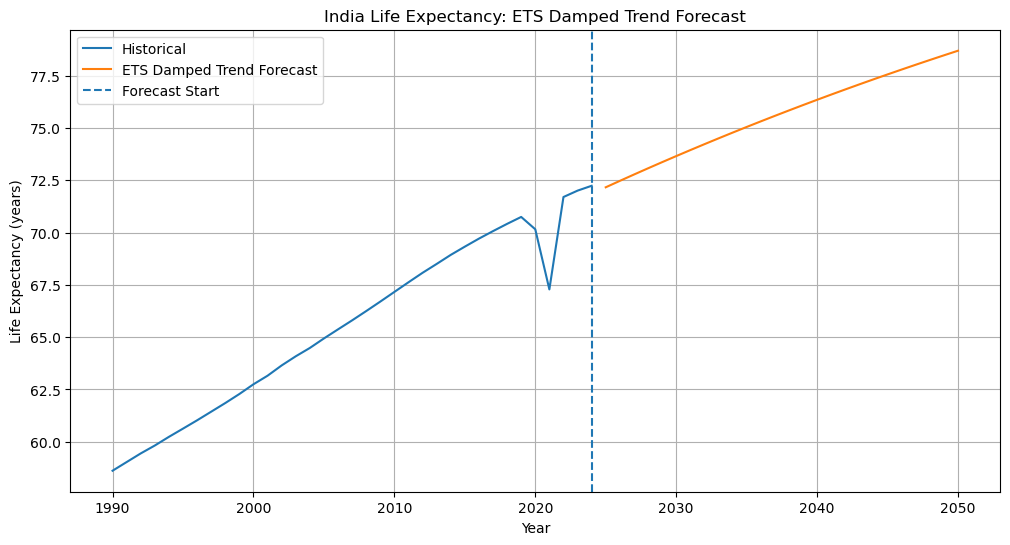

In [248]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_forecast["Year"],
    india_forecast["Life_Expectancy"],
    label="Historical"
)

plt.plot(
    india_ets_df["Year"],
    india_ets_df["Forecast"],
    label="ETS Damped Trend Forecast"
)

plt.axvline(
    x=2024,
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("India Life Expectancy: ETS Damped Trend Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [249]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# Make sure data is sorted
germany_data = germany_forecast.sort_values("Year").copy()

# Life expectancy series
germany_y = germany_data["Life_Expectancy"].dropna()

# Fit ETS with damped trend
germany_ets = ExponentialSmoothing(
    germany_y,
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
).fit()

# Forecast 2025–2050
germany_ets_forecast = germany_ets.forecast(26)

germany_ets_2050 = pd.DataFrame({
    "Year": range(2025, 2051),
    "Forecast": germany_ets_forecast.values
})

print("GERMANY ETS DAMPED TREND")
print(germany_ets_2050)

print("\nGermany 2050 ETS forecast:")
print(
    germany_ets_2050[
        germany_ets_2050["Year"] == 2050
    ]
)

GERMANY ETS DAMPED TREND
    Year   Forecast
0   2025  80.770639
1   2026  80.729603
2   2027  80.690521
3   2028  80.653301
4   2029  80.617853
5   2030  80.584094
6   2031  80.551942
7   2032  80.521322
8   2033  80.492160
9   2034  80.464387
10  2035  80.437937
11  2036  80.412747
12  2037  80.388757
13  2038  80.365909
14  2039  80.344149
15  2040  80.323426
16  2041  80.303690
17  2042  80.284894
18  2043  80.266993
19  2044  80.249944
20  2045  80.233708
21  2046  80.218245
22  2047  80.203518
23  2048  80.189493
24  2049  80.176136
25  2050  80.163415

Germany 2050 ETS forecast:
    Year   Forecast
25  2050  80.163415


In [250]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

# Final Germany ARIMA(0,1,1)
germany_arima_final = ARIMA(
    germany_forecast["Life_Expectancy"],
    order=(0, 1, 1)
).fit()

# Forecast from 2025 to 2050
germany_arima_2050 = germany_arima_final.get_forecast(
    steps=2050 - germany_forecast["Year"].max()
)

germany_arima_2050_summary = germany_arima_2050.summary_frame(alpha=0.05)

# Create forecast years
germany_arima_years = range(
    germany_forecast["Year"].max() + 1,
    2051
)

germany_arima_2050_df = pd.DataFrame({
    "Year": list(germany_arima_years),
    "Forecast": germany_arima_2050_summary["mean"].values,
    "Lower_CI": germany_arima_2050_summary["mean_ci_lower"].values,
    "Upper_CI": germany_arima_2050_summary["mean_ci_upper"].values
})

print("GERMANY ARIMA(0,1,1) — 2025–2050")
print(germany_arima_2050_df.head())
print("\n2050 forecast:")
print(germany_arima_2050_df.tail(1))

GERMANY ARIMA(0,1,1) — 2025–2050
   Year   Forecast   Lower_CI   Upper_CI
0  2025  80.764177  80.179093  81.349261
1  2026  80.764177  79.895494  81.632860
2  2027  80.764177  79.683946  81.844408
3  2028  80.764177  79.507520  82.020834
4  2029  80.764177  79.352981  82.175373

2050 forecast:
    Year   Forecast   Lower_CI   Upper_CI
25  2050  80.764177  77.500818  84.027536


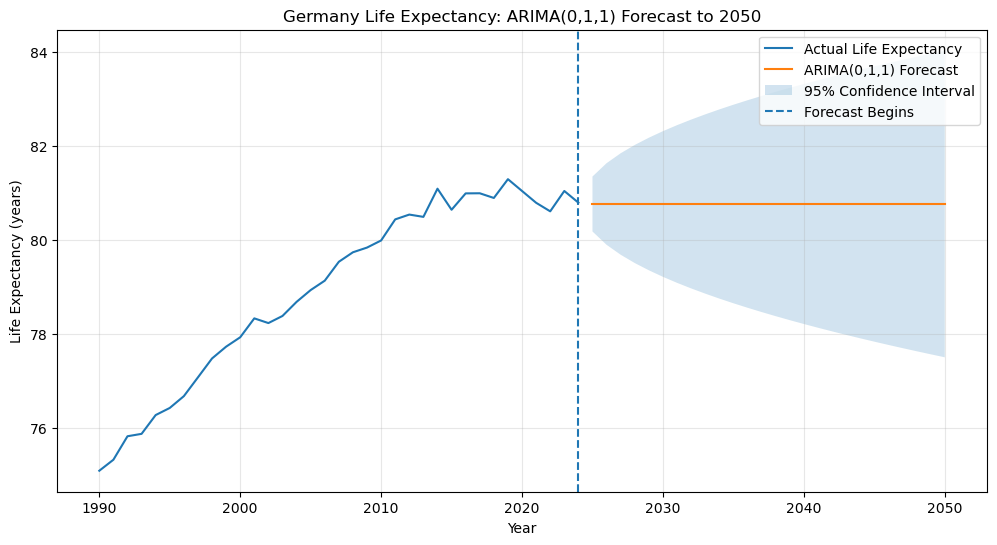

In [251]:
plt.figure(figsize=(12, 6))

# Historical data
plt.plot(
    germany_forecast["Year"],
    germany_forecast["Life_Expectancy"],
    label="Actual Life Expectancy"
)

# ARIMA forecast
plt.plot(
    germany_arima_2050_df["Year"],
    germany_arima_2050_df["Forecast"],
    label="ARIMA(0,1,1) Forecast"
)

# Confidence interval
plt.fill_between(
    germany_arima_2050_df["Year"],
    germany_arima_2050_df["Lower_CI"],
    germany_arima_2050_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    x=2024,
    linestyle="--",
    label="Forecast Begins"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("Germany Life Expectancy: ARIMA(0,1,1) Forecast to 2050")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [252]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Germany historical data
germany_trend = germany_forecast[
    ["Year", "Life_Expectancy"]
].dropna().copy()

# Predictor
X = germany_trend[["Year"]]
y = germany_trend["Life_Expectancy"]

# Fit long-term linear trend
germany_trend_model = LinearRegression()
germany_trend_model.fit(X, y)

# Forecast 2025–2050
future_years = pd.DataFrame({
    "Year": range(2025, 2051)
})

future_years["Forecast"] = germany_trend_model.predict(
    future_years[["Year"]]
)

print("Germany upward trend forecast:")
print(future_years.head())
print("\n2050 forecast:")
print(future_years.tail(1))

Germany upward trend forecast:
   Year   Forecast
0  2025  82.258725
1  2026  82.441223
2  2027  82.623721
3  2028  82.806219
4  2029  82.988717

2050 forecast:
    Year  Forecast
25  2050  86.82118


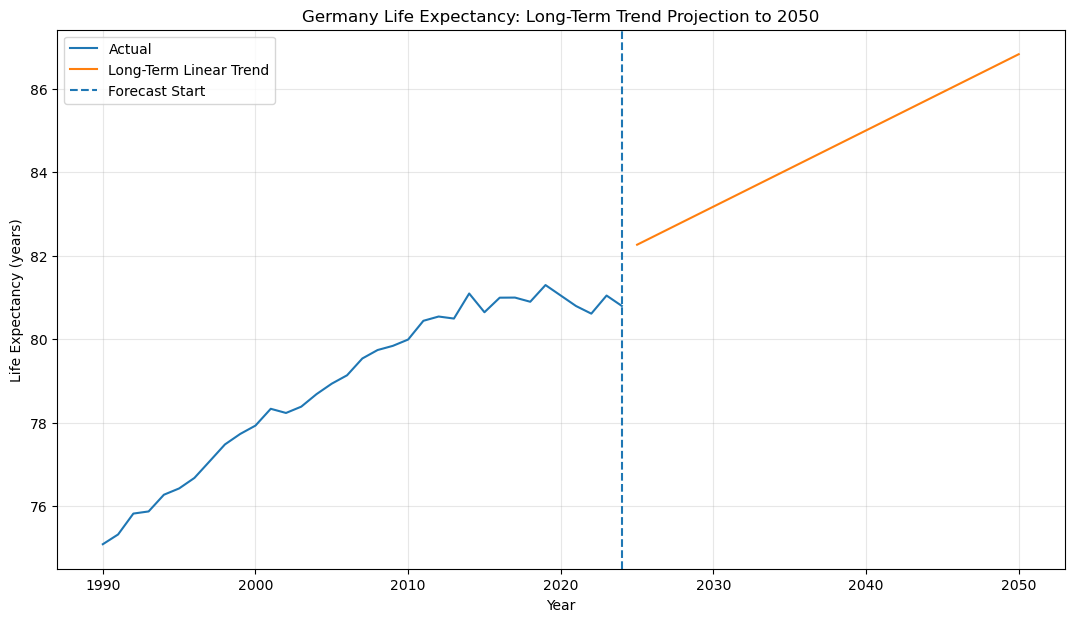

In [253]:
plt.figure(figsize=(13, 7))

# Historical
plt.plot(
    germany_trend["Year"],
    germany_trend["Life_Expectancy"],
    label="Actual"
)

# Long-term upward trend
plt.plot(
    future_years["Year"],
    future_years["Forecast"],
    label="Long-Term Linear Trend"
)

# Forecast boundary
plt.axvline(
    2024,
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "Germany Life Expectancy: Long-Term Trend Projection to 2050"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [254]:
print(
    "Germany 2024:",
    germany_forecast["Life_Expectancy"].iloc[-1]
)

print(
    "Germany 2050 trend forecast:",
    future_years["Forecast"].iloc[-1]
)

print(
    "Increase:",
    future_years["Forecast"].iloc[-1]
    - germany_forecast["Life_Expectancy"].iloc[-1]
)

Germany 2024: 80.79268293
Germany 2050 trend forecast: 86.82117982148458
Increase: 6.028496891484579


# Germany — Scenario 1: ARIMA Baseline to 2050

Germany historical data:
Year
2020    81.041463
2021    80.790244
2022    80.608049
2023    81.041463
2024    80.792683
Name: Life_Expectancy, dtype: float64

Last observed year: 2024
Last observed life expectancy: 80.79268293

Germany ARIMA(0,1,1) fitted successfully.
                               SARIMAX Results                                
Dep. Variable:        Life_Expectancy   No. Observations:                   35
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  -7.146
Date:                Wed, 19 Aug 2026   AIC                             18.292
Time:                        17:01:45   BIC                             21.344
Sample:                             0   HQIC                            19.333
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No sup

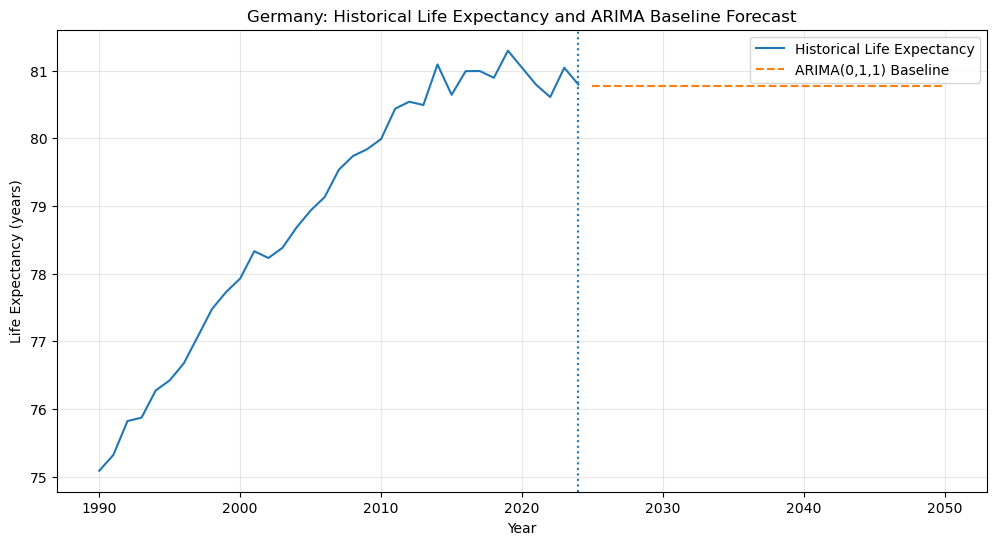

In [256]:
# ============================================================
# SCENARIO 1 — GERMANY ARIMA BASELINE FORECAST TO 2050
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------------------------
# 1. Prepare Germany life expectancy series
# ------------------------------------------------------------

# Use your existing Germany dataframe
germany_baseline_data = germany_forecast.copy()

# Make sure data are sorted by year
germany_baseline_data = germany_baseline_data.sort_values("Year")

# Extract life expectancy
germany_life = (
    germany_baseline_data
    .set_index("Year")["Life_Expectancy"]
    .dropna()
)

print("Germany historical data:")
print(germany_life.tail())
print("\nLast observed year:", germany_life.index.max())
print("Last observed life expectancy:", germany_life.iloc[-1])


# ------------------------------------------------------------
# 2. Fit the selected Germany ARIMA model
# ------------------------------------------------------------

germany_arima_baseline = ARIMA(
    germany_life,
    order=(0, 1, 1)
)

germany_arima_fit = germany_arima_baseline.fit()

print("\nGermany ARIMA(0,1,1) fitted successfully.")
print(germany_arima_fit.summary())


# ------------------------------------------------------------
# 3. Forecast from 2025 to 2050
# ------------------------------------------------------------

forecast_years = list(range(2025, 2051))

germany_arima_forecast = germany_arima_fit.forecast(
    steps=len(forecast_years)
)

germany_baseline_2050 = pd.DataFrame({
    "Year": forecast_years,
    "Forecast": germany_arima_forecast.values
})

print("\n🇩🇪 GERMANY ARIMA BASELINE")
print(germany_baseline_2050)

print("\nGermany 2050 baseline forecast:")
print(
    germany_baseline_2050[
        germany_baseline_2050["Year"] == 2050
    ]
)


# ------------------------------------------------------------
# 4. Plot historical data + baseline forecast
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    germany_life.index,
    germany_life.values,
    label="Historical Life Expectancy"
)

plt.plot(
    germany_baseline_2050["Year"],
    germany_baseline_2050["Forecast"],
    linestyle="--",
    label="ARIMA(0,1,1) Baseline"
)

plt.axvline(
    x=2024,
    linestyle=":"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "Germany: Historical Life Expectancy and ARIMA Baseline Forecast"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [257]:
# ============================================================
# SCENARIO 2 — GERMANY LONG-TERM IMPROVEMENT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Use Germany historical data
germany_trend_data = germany_forecast.copy()

germany_trend_data = (
    germany_trend_data
    .sort_values("Year")
    .dropna(subset=["Year", "Life_Expectancy"])
)

# ------------------------------------------------------------
# Fit a long-term historical trend
# ------------------------------------------------------------

X = germany_trend_data[["Year"]]
y = germany_trend_data["Life_Expectancy"]

germany_trend_model = LinearRegression()
germany_trend_model.fit(X, y)

# Historical trend parameters
germany_slope = germany_trend_model.coef_[0]
germany_intercept = germany_trend_model.intercept_

print("Germany long-term annual trend:")
print(f"{germany_slope:.4f} years of life expectancy per year")

print("\nGermany trend equation:")
print(f"Life Expectancy = {germany_intercept:.4f} + "
      f"({germany_slope:.6f} × Year)")

Germany long-term annual trend:
0.1825 years of life expectancy per year

Germany trend equation:
Life Expectancy = -287.3002 + (0.182498 × Year)


In [258]:
# ------------------------------------------------------------
# Forecast 2025–2050 under long-term improvement
# ------------------------------------------------------------

scenario_years = np.arange(2025, 2051)

germany_longterm_forecast = germany_trend_model.predict(
    scenario_years.reshape(-1, 1)
)

germany_scenario2 = pd.DataFrame({
    "Year": scenario_years,
    "Forecast": germany_longterm_forecast
})

print("🇩🇪 GERMANY — SCENARIO 2")
print(germany_scenario2)

print("\n2050 Long-Term Improvement Forecast:")
print(
    germany_scenario2[
        germany_scenario2["Year"] == 2050
    ]
)

🇩🇪 GERMANY — SCENARIO 2
    Year   Forecast
0   2025  82.258725
1   2026  82.441223
2   2027  82.623721
3   2028  82.806219
4   2029  82.988717
5   2030  83.171216
6   2031  83.353714
7   2032  83.536212
8   2033  83.718710
9   2034  83.901208
10  2035  84.083707
11  2036  84.266205
12  2037  84.448703
13  2038  84.631201
14  2039  84.813700
15  2040  84.996198
16  2041  85.178696
17  2042  85.361194
18  2043  85.543692
19  2044  85.726191
20  2045  85.908689
21  2046  86.091187
22  2047  86.273685
23  2048  86.456183
24  2049  86.638682
25  2050  86.821180

2050 Long-Term Improvement Forecast:
    Year  Forecast
25  2050  86.82118


C:\Users\Admin\Documents\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


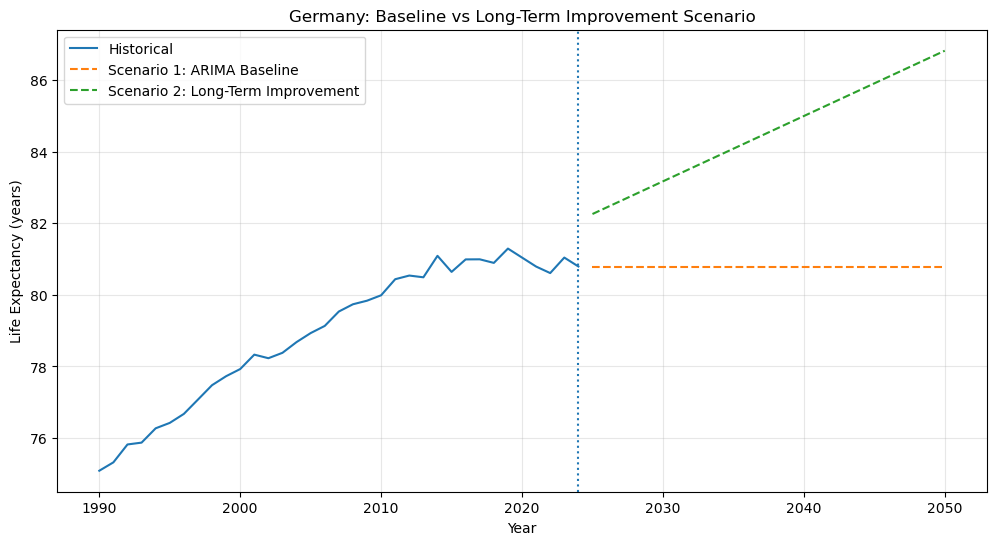

In [259]:
# ============================================================
# COMPARE BASELINE VS LONG-TERM IMPROVEMENT
# ============================================================

plt.figure(figsize=(12, 6))

# Historical
plt.plot(
    germany_life.index,
    germany_life.values,
    label="Historical"
)

# ARIMA baseline
plt.plot(
    germany_baseline_2050["Year"],
    germany_baseline_2050["Forecast"],
    linestyle="--",
    label="Scenario 1: ARIMA Baseline"
)

# Long-term improvement
plt.plot(
    germany_scenario2["Year"],
    germany_scenario2["Forecast"],
    linestyle="--",
    label="Scenario 2: Long-Term Improvement"
)

plt.axvline(
    2024,
    linestyle=":"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "Germany: Baseline vs Long-Term Improvement Scenario"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [260]:
# ============================================================
# SCENARIO 3 — GERMANY PHYSICIAN DENSITY
# ============================================================

germany_physician_data = (
    df[df["Country"] == "Germany"]
    [
        [
            "Year",
            "Life_Expectancy",
            "Physician_Density"
        ]
    ]
    .dropna()
    .sort_values("Year")
    .reset_index(drop=True)
)

print(germany_physician_data.head())
print()
print(germany_physician_data.tail())

   Year  Life_Expectancy  Physician_Density
0  1990        75.085634              2.745
1  1991        75.319512              2.745
2  1992        75.819512              2.816
3  1993        75.870732              2.904
4  1994        76.270732              2.977

    Year  Life_Expectancy  Physician_Density
30  2020        81.041463              4.443
31  2021        80.790244              4.503
32  2022        80.608049              4.534
33  2023        81.041463              4.534
34  2024        80.792683              4.534


In [261]:
print("GERMANY PHYSICIAN DENSITY")

print(
    germany_physician_data[
        ["Year", "Physician_Density"]
    ].to_string(index=False)
)

print("\nPhysician density change:")

print(
    germany_physician_data["Physician_Density"].iloc[-1]
    - germany_physician_data["Physician_Density"].iloc[0]
)

print("\nStarting value:",
      germany_physician_data["Physician_Density"].iloc[0])

print("Latest value:",
      germany_physician_data["Physician_Density"].iloc[-1])

GERMANY PHYSICIAN DENSITY
 Year  Physician_Density
 1990              2.745
 1991              2.745
 1992              2.816
 1993              2.904
 1994              2.977
 1995              3.041
 1996              3.087
 1997              3.103
 1998              3.164
 1999              3.213
 2000              3.263
 2001              3.310
 2002              3.338
 2003              3.369
 2004              3.392
 2005              3.413
 2006              3.465
 2007              3.528
 2008              3.584
 2009              3.662
 2010              3.757
 2011              3.849
 2012              3.922
 2013              4.015
 2014              4.088
 2015              4.120
 2016              4.166
 2017              4.226
 2018              4.287
 2019              4.373
 2020              4.443
 2021              4.503
 2022              4.534
 2023              4.534
 2024              4.534

Physician density change:
1.7889999999999997

Starting value: 2.745
Lates

In [262]:
germany_physician_corr = (
    germany_physician_data[
        ["Life_Expectancy", "Physician_Density"]
    ]
    .corr()
)

print("GERMANY — PHYSICIAN DENSITY / LIFE EXPECTANCY")
print(germany_physician_corr)

GERMANY — PHYSICIAN DENSITY / LIFE EXPECTANCY
                   Life_Expectancy  Physician_Density
Life_Expectancy           1.000000           0.943892
Physician_Density         0.943892           1.000000


In [263]:
# ============================================================
# GERMANY SCENARIO 3 — PHYSICIAN DENSITY IMPROVEMENT
# STEP 2: HISTORICAL ANNUAL RATE
# ============================================================

first_year = germany_physician_data["Year"].iloc[0]
last_year = germany_physician_data["Year"].iloc[-1]

first_physician = germany_physician_data["Physician_Density"].iloc[0]
last_physician = germany_physician_data["Physician_Density"].iloc[-1]

years_elapsed = last_year - first_year

annual_physician_change = (
    last_physician - first_physician
) / years_elapsed

print("First year:", first_year)
print("Last year:", last_year)

print("\nStarting physician density:", first_physician)
print("Latest physician density:", last_physician)

print("\nAnnual average change:")
print(round(annual_physician_change, 4))

First year: 1990
Last year: 2024

Starting physician density: 2.745
Latest physician density: 4.534

Annual average change:
0.0526


In [264]:
# ============================================================
# PROJECT PHYSICIAN DENSITY TO 2050
# ============================================================

future_years = np.arange(2025, 2051)

physician_2050 = (
    last_physician
    + annual_physician_change
    * (future_years - last_year)
)

germany_physician_scenario = pd.DataFrame({
    "Year": future_years,
    "Physician_Density": physician_2050
})

print(germany_physician_scenario)

print("\n2050 projected physician density:")
print(
    germany_physician_scenario[
        germany_physician_scenario["Year"] == 2050
    ]
)

    Year  Physician_Density
0   2025           4.586618
1   2026           4.639235
2   2027           4.691853
3   2028           4.744471
4   2029           4.797088
5   2030           4.849706
6   2031           4.902324
7   2032           4.954941
8   2033           5.007559
9   2034           5.060176
10  2035           5.112794
11  2036           5.165412
12  2037           5.218029
13  2038           5.270647
14  2039           5.323265
15  2040           5.375882
16  2041           5.428500
17  2042           5.481118
18  2043           5.533735
19  2044           5.586353
20  2045           5.638971
21  2046           5.691588
22  2047           5.744206
23  2048           5.796824
24  2049           5.849441
25  2050           5.902059

2050 projected physician density:
    Year  Physician_Density
25  2050           5.902059


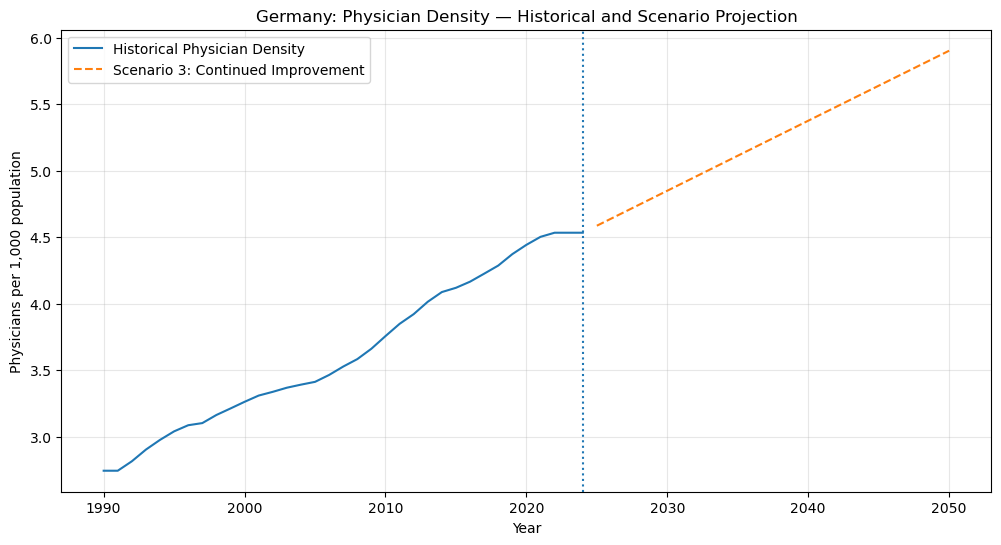

In [265]:
plt.figure(figsize=(12, 6))

plt.plot(
    germany_physician_data["Year"],
    germany_physician_data["Physician_Density"],
    label="Historical Physician Density"
)

plt.plot(
    germany_physician_scenario["Year"],
    germany_physician_scenario["Physician_Density"],
    linestyle="--",
    label="Scenario 3: Continued Improvement"
)

plt.axvline(
    2024,
    linestyle=":"
)

plt.xlabel("Year")
plt.ylabel("Physicians per 1,000 population")

plt.title(
    "Germany: Physician Density — Historical and Scenario Projection"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

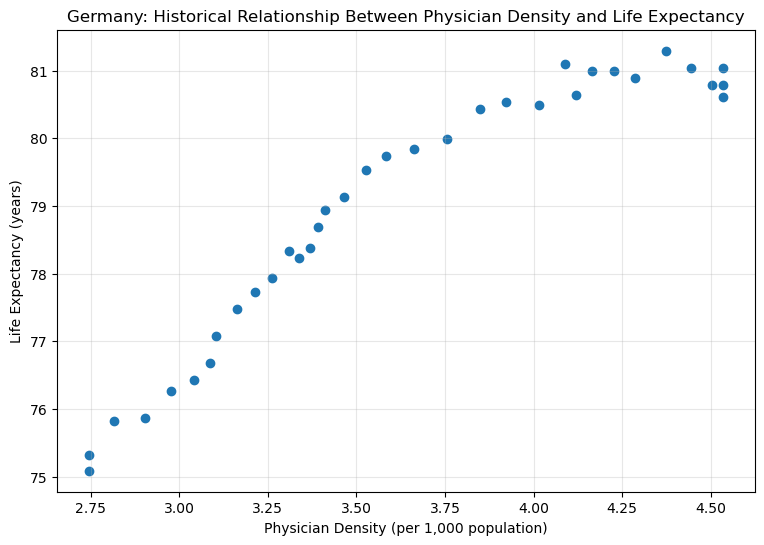

In [266]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    germany_physician_data["Physician_Density"],
    germany_physician_data["Life_Expectancy"]
)

plt.xlabel("Physician Density (per 1,000 population)")
plt.ylabel("Life Expectancy (years)")
plt.title(
    "Germany: Historical Relationship Between Physician Density and Life Expectancy"
)

plt.grid(True, alpha=0.3)
plt.show()

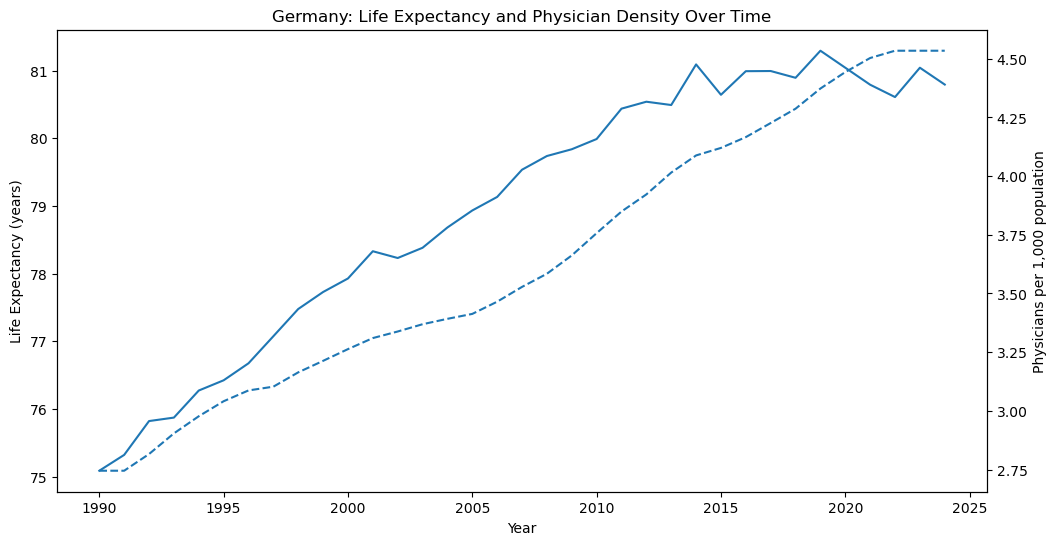

In [267]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    germany_physician_data["Year"],
    germany_physician_data["Life_Expectancy"],
    label="Life Expectancy"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Life Expectancy (years)")

ax2 = ax1.twinx()

ax2.plot(
    germany_physician_data["Year"],
    germany_physician_data["Physician_Density"],
    linestyle="--",
    label="Physician Density"
)

ax2.set_ylabel("Physicians per 1,000 population")

plt.title(
    "Germany: Life Expectancy and Physician Density Over Time"
)

plt.show()

In [268]:
# ============================================================
# GERMANY — SCENARIO 3
# PHYSICIAN DENSITY IMPROVEMENT
# STEP 1: HISTORICAL DATA
# ============================================================

germany_physician = germany_indicators[
    [
        "Year",
        "Life_Expectancy",
        "Physician_Density"
    ]
].copy()

germany_physician = (
    germany_physician
    .dropna()
    .sort_values("Year")
    .reset_index(drop=True)
)

display(germany_physician.head())
display(germany_physician.tail())

,Year,Life_Expectancy,Physician_Density
0,1990,75.085634,2.745
1,1991,75.319512,2.745
2,1992,75.819512,2.816
3,1993,75.870732,2.904
4,1994,76.270732,2.977


,Year,Life_Expectancy,Physician_Density
30,2020,81.041463,4.443
31,2021,80.790244,4.503
32,2022,80.608049,4.534
33,2023,81.041463,4.534
34,2024,80.792683,4.534


In [269]:
# ============================================================
# STEP 2 — HISTORICAL ASSOCIATION
# ============================================================

physician_corr = germany_physician[
    [
        "Life_Expectancy",
        "Physician_Density"
    ]
].corr().loc[
    "Life_Expectancy",
    "Physician_Density"
]

print(
    "Germany correlation between Physician Density "
    "and Life Expectancy:",
    round(physician_corr, 4)
)

Germany correlation between Physician Density and Life Expectancy: 0.9439


In [270]:
# ============================================================
# STEP 3 — SINGLE-INDICATOR SCENARIO MODEL
# ============================================================

from sklearn.linear_model import LinearRegression

X_physician = germany_physician[
    ["Physician_Density"]
]

y_life = germany_physician[
    "Life_Expectancy"
]

physician_model = LinearRegression()

physician_model.fit(
    X_physician,
    y_life
)

print("Physician Density coefficient:",
      physician_model.coef_[0])

print("Intercept:",
      physician_model.intercept_)

print("R²:",
      physician_model.score(X_physician, y_life))

Physician Density coefficient: 3.192628663022638
Intercept: 67.3462032041287
R²: 0.8909326911201721


In [271]:
# ============================================================
# STEP 4 — PROJECT PHYSICIAN DENSITY
# ============================================================

first_year = germany_physician["Year"].iloc[0]
last_year = germany_physician["Year"].iloc[-1]

first_value = germany_physician[
    "Physician_Density"
].iloc[0]

last_value = germany_physician[
    "Physician_Density"
].iloc[-1]

years_elapsed = last_year - first_year

annual_change = (
    last_value - first_value
) / years_elapsed

print("Historical annual change:",
      round(annual_change, 4))

Historical annual change: 0.0526


In [272]:
future_years = np.arange(2025, 2051)

scenario_physician_density = (
    last_value
    + annual_change *
    (future_years - last_year)
)

germany_physician_scenario = pd.DataFrame({
    "Year": future_years,
    "Physician_Density": scenario_physician_density
})

display(germany_physician_scenario.head())
display(germany_physician_scenario.tail())

,Year,Physician_Density
0,2025,4.586618
1,2026,4.639235
2,2027,4.691853
3,2028,4.744471
4,2029,4.797088


,Year,Physician_Density
21,2046,5.691588
22,2047,5.744206
23,2048,5.796824
24,2049,5.849441
25,2050,5.902059


In [273]:
# ============================================================
# STEP 5 — CONVERT PHYSICIAN SCENARIO
# INTO LIFE EXPECTANCY SCENARIO
# ============================================================

germany_physician_scenario[
    "Life_Expectancy_Scenario"
] = physician_model.predict(
    germany_physician_scenario[
        ["Physician_Density"]
    ]
)

display(germany_physician_scenario.head())
display(germany_physician_scenario.tail())

,Year,Physician_Density,Life_Expectancy_Scenario
0,2025,4.586618,81.989570
1,2026,4.639235,82.157559
2,2027,4.691853,82.325547
3,2028,4.744471,82.493536
4,2029,4.797088,82.661525


,Year,Physician_Density,Life_Expectancy_Scenario
21,2046,5.691588,85.517331
22,2047,5.744206,85.685320
23,2048,5.796824,85.853308
24,2049,5.849441,86.021297
25,2050,5.902059,86.189285


In [274]:
# ============================================================
# STEP 6 — ARIMA BASELINE VS PHYSICIAN SCENARIO
# ============================================================

germany_physician_comparison = pd.merge(
    germany_2050_df[
        ["Year", "Forecast"]
    ],
    germany_physician_scenario[
        [
            "Year",
            "Life_Expectancy_Scenario"
        ]
    ],
    on="Year",
    how="inner"
)

germany_physician_comparison = (
    germany_physician_comparison
    .rename(
        columns={
            "Forecast": "ARIMA_Baseline"
        }
    )
)

germany_physician_comparison[
    "Scenario_Difference"
] = (
    germany_physician_comparison[
        "Life_Expectancy_Scenario"
    ]
    -
    germany_physician_comparison[
        "ARIMA_Baseline"
    ]
)

display(
    germany_physician_comparison.head()
)

display(
    germany_physician_comparison.tail()
)

,Year,ARIMA_Baseline,Life_Expectancy_Scenario,Scenario_Difference
0,2025,80.764177,81.989570,1.225393
1,2026,80.764177,82.157559,1.393382
2,2027,80.764177,82.325547,1.561370
3,2028,80.764177,82.493536,1.729359
4,2029,80.764177,82.661525,1.897348


,Year,ARIMA_Baseline,Life_Expectancy_Scenario,Scenario_Difference
21,2046,80.764177,85.517331,4.753154
22,2047,80.764177,85.685320,4.921143
23,2048,80.764177,85.853308,5.089131
24,2049,80.764177,86.021297,5.257120
25,2050,80.764177,86.189285,5.425108


In [275]:
germany_physician_2050 = (
    germany_physician_comparison[
        germany_physician_comparison["Year"] == 2050
    ]
)

print("🇩🇪 GERMANY — 2050 PHYSICIAN DENSITY SCENARIO")
print()

display(germany_physician_2050)

🇩🇪 GERMANY — 2050 PHYSICIAN DENSITY SCENARIO



,Year,ARIMA_Baseline,Life_Expectancy_Scenario,Scenario_Difference
25,2050,80.764177,86.189285,5.425108


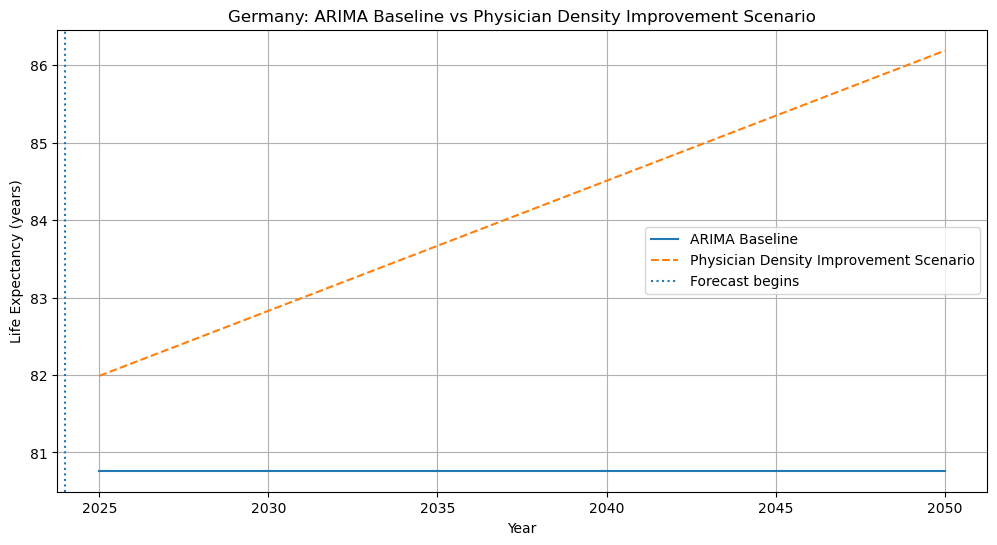

In [276]:
# ============================================================
# STEP 8 — PLOT
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    germany_physician_comparison["Year"],
    germany_physician_comparison["ARIMA_Baseline"],
    label="ARIMA Baseline"
)

plt.plot(
    germany_physician_comparison["Year"],
    germany_physician_comparison[
        "Life_Expectancy_Scenario"
    ],
    linestyle="--",
    label="Physician Density Improvement Scenario"
)

plt.axvline(
    2024,
    linestyle=":",
    label="Forecast begins"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")

plt.title(
    "Germany: ARIMA Baseline vs Physician Density Improvement Scenario"
)

plt.legend()
plt.grid(True)

plt.show()

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [278]:
# ============================================================
# REUSABLE SINGLE-INDICATOR SCENARIO FUNCTION
# ============================================================

def create_indicator_scenario(
    indicator_df,
    arima_df,
    indicator,
    direction="improve",
    country="Germany"
):
    
    # ----------------------------------------
    # 1. Historical data
    # ----------------------------------------
    
    data = indicator_df[
        ["Year", "Life_Expectancy", indicator]
    ].dropna().sort_values("Year").reset_index(drop=True)
    
    # ----------------------------------------
    # 2. Single-indicator regression
    # ----------------------------------------
    
    X = data[[indicator]]
    y = data["Life_Expectancy"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    # ----------------------------------------
    # 3. Historical indicator trend
    # ----------------------------------------
    
    first_year = data["Year"].iloc[0]
    last_year = data["Year"].iloc[-1]
    
    first_value = data[indicator].iloc[0]
    last_value = data[indicator].iloc[-1]
    
    years_elapsed = last_year - first_year
    
    annual_change = (
        last_value - first_value
    ) / years_elapsed
    
    # ----------------------------------------
    # 4. Future years
    # ----------------------------------------
    
    future_years = np.arange(2025, 2051)
    
    # ----------------------------------------
    # 5. Improvement / deterioration
    # ----------------------------------------
    
    if direction == "improve":
        
        scenario_values = (
            last_value
            + annual_change *
            (future_years - last_year)
        )
        
    elif direction == "deteriorate":
        
        scenario_values = (
            last_value
            - annual_change *
            (future_years - last_year)
        )
        
    else:
        raise ValueError(
            "direction must be 'improve' or 'deteriorate'"
        )
    
    # ----------------------------------------
    # 6. Prevent unrealistic negative values
    # ----------------------------------------
    
    scenario_values = np.maximum(
        scenario_values,
        0
    )
    
    # ----------------------------------------
    # 7. Predict life expectancy
    # ----------------------------------------
    
    scenario_df = pd.DataFrame({
        "Year": future_years,
        indicator: scenario_values
    })
    
    scenario_df["Life_Expectancy_Scenario"] = (
        model.predict(
            scenario_df[[indicator]]
        )
    )
    
    # ----------------------------------------
    # 8. Merge with ARIMA baseline
    # ----------------------------------------
    
    comparison = pd.merge(
        arima_df[
            ["Year", "Forecast"]
        ],
        scenario_df[
            [
                "Year",
                indicator,
                "Life_Expectancy_Scenario"
            ]
        ],
        on="Year",
        how="inner"
    )
    
    comparison = comparison.rename(
        columns={
            "Forecast": "ARIMA_Baseline"
        }
    )
    
    comparison["Difference_vs_ARIMA"] = (
        comparison["Life_Expectancy_Scenario"]
        -
        comparison["ARIMA_Baseline"]
    )
    
    # ----------------------------------------
    # 9. Print summary
    # ----------------------------------------
    
    print("=" * 60)
    print(country.upper())
    print(indicator)
    print("Scenario:", direction)
    print("=" * 60)
    
    print(
        "Historical annual change:",
        round(annual_change, 4)
    )
    
    print(
        "Regression coefficient:",
        round(model.coef_[0], 4)
    )
    
    print(
        "Regression R²:",
        round(model.score(X, y), 4)
    )
    
    result_2050 = comparison[
        comparison["Year"] == 2050
    ]
    
    print("\n2050 result:")
    display(result_2050)
    
    return comparison, model

In [279]:
germany_physician_improve, germany_physician_model = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Physician_Density",
    direction="improve",
    country="Germany"
)

GERMANY
Physician_Density
Scenario: improve
Historical annual change: 0.0526
Regression coefficient: 3.1926
Regression R²: 0.8909

2050 result:


,Year,ARIMA_Baseline,Physician_Density,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,5.902059,86.189285,5.425108


In [280]:
germany_physician_decline, _ = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Physician_Density",
    direction="deteriorate",
    country="Germany"
)

GERMANY
Physician_Density
Scenario: deteriorate
Historical annual change: 0.0526
Regression coefficient: 3.1926
Regression R²: 0.8909

2050 result:


,Year,ARIMA_Baseline,Physician_Density,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,3.165941,77.453878,-3.310299


In [281]:
germany_beds_improve, germany_beds_model = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Hospital_Beds_Per_1000",
    direction="improve",
    country="Germany"
)

GERMANY
Hospital_Beds_Per_1000
Scenario: improve
Historical annual change: -0.0838
Regression coefficient: -2.4024
Regression R²: 0.9516

2050 result:


,Year,ARIMA_Baseline,Hospital_Beds_Per_1000,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,5.370589,86.86236,6.098183


In [282]:
germany_beds_decline, _ = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Hospital_Beds_Per_1000",
    direction="deteriorate",
    country="Germany"
)

GERMANY
Hospital_Beds_Per_1000
Scenario: deteriorate
Historical annual change: -0.0838
Regression coefficient: -2.4024
Regression R²: 0.9516

2050 result:


,Year,ARIMA_Baseline,Hospital_Beds_Per_1000,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,9.729411,76.390924,-4.373253


In [283]:
germany_expenditure_improve, germany_expenditure_model = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Health_Expenditure_y",
    direction="improve",
    country="Germany"
)

GERMANY
Health_Expenditure_y
Scenario: improve
Historical annual change: 0.1136
Regression coefficient: 1.4809
Regression R²: 0.8083

2050 result:


,Year,ARIMA_Baseline,Health_Expenditure_y,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,15.219652,86.263784,5.499607


In [284]:
germany_expenditure_decline, _ = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "Health_Expenditure_y",
    direction="deteriorate",
    country="Germany"
)

GERMANY
Health_Expenditure_y
Scenario: deteriorate
Historical annual change: 0.1136
Regression coefficient: 1.4809
Regression R²: 0.8083

2050 result:


,Year,ARIMA_Baseline,Health_Expenditure_y,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,9.313454,77.51729,-3.246887


In [285]:
germany_uhc_improve, germany_uhc_model = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "UHC_Coverage_Index",
    direction="improve",
    country="Germany"
)

GERMANY
UHC_Coverage_Index
Scenario: improve
Historical annual change: 0.0
Regression coefficient: 0.4103
Regression R²: 0.1958

2050 result:


,Year,ARIMA_Baseline,UHC_Coverage_Index,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,84.0,78.973757,-1.79042


In [286]:
germany_uhc_decline, _ = create_indicator_scenario(
    germany_indicators,
    germany_2050_df,
    "UHC_Coverage_Index",
    direction="deteriorate",
    country="Germany"
)

GERMANY
UHC_Coverage_Index
Scenario: deteriorate
Historical annual change: 0.0
Regression coefficient: 0.4103
Regression R²: 0.1958

2050 result:


,Year,ARIMA_Baseline,UHC_Coverage_Index,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,84.0,78.973757,-1.79042


In [287]:
# ============================================================
# GERMANY — LOWER OUT-OF-POCKET EXPENDITURE
# ============================================================

germany_oop = germany_indicators[
    [
        "Year",
        "Life_Expectancy",
        "Out_of_Pocket"
    ]
].dropna().sort_values("Year")

X = germany_oop[
    ["Out_of_Pocket"]
]

y = germany_oop[
    "Life_Expectancy"
]

germany_oop_model = LinearRegression()

germany_oop_model.fit(
    X,
    y
)

first_value = germany_oop[
    "Out_of_Pocket"
].iloc[0]

last_value = germany_oop[
    "Out_of_Pocket"
].iloc[-1]

first_year = germany_oop["Year"].iloc[0]
last_year = germany_oop["Year"].iloc[-1]

annual_change = (
    last_value - first_value
) / (last_year - first_year)

future_years = np.arange(
    2025,
    2051
)

# IMPROVEMENT = LOWER OOP
oop_improvement = (
    last_value
    - abs(annual_change)
    * (future_years - last_year)
)

oop_scenario = pd.DataFrame({
    "Year": future_years,
    "Out_of_Pocket": oop_improvement
})

oop_scenario[
    "Life_Expectancy_Scenario"
] = germany_oop_model.predict(
    oop_scenario[
        ["Out_of_Pocket"]
    ]
)

germany_oop_comparison = pd.merge(
    germany_2050_df[
        ["Year", "Forecast"]
    ],
    oop_scenario,
    on="Year"
)

germany_oop_comparison = (
    germany_oop_comparison
    .rename(
        columns={
            "Forecast": "ARIMA_Baseline"
        }
    )
)

germany_oop_comparison[
    "Difference_vs_ARIMA"
] = (
    germany_oop_comparison[
        "Life_Expectancy_Scenario"
    ]
    -
    germany_oop_comparison[
        "ARIMA_Baseline"
    ]
)

display(
    germany_oop_comparison[
        germany_oop_comparison["Year"] == 2050
    ]
)

,Year,ARIMA_Baseline,Out_of_Pocket,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,80.764177,8.097202,84.666716,3.902539


In [288]:
# ============================================================
# GERMANY — FINAL SCENARIO SUMMARY
# ============================================================

germany_scenarios_2050 = pd.DataFrame({

    "Scenario": [
        "ARIMA Baseline",
        "Physician Density Improvement",
        "Hospital Beds Improvement",
        "Health Expenditure Improvement",
        "UHC Coverage Improvement",
        "Out-of-Pocket Reduction",
    ],

    "Life_Expectancy_2050": [

        germany_2050_df.loc[
            germany_2050_df["Year"] == 2050,
            "Forecast"
        ].iloc[0],

        germany_physician_improve.loc[
            germany_physician_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        germany_beds_improve.loc[
            germany_beds_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        germany_expenditure_improve.loc[
            germany_expenditure_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        germany_uhc_improve.loc[
            germany_uhc_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        germany_oop_comparison.loc[
            germany_oop_comparison["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],
    ]
})

germany_scenarios_2050[
    "Difference_from_ARIMA"
] = (
    germany_scenarios_2050[
        "Life_Expectancy_2050"
    ]
    -
    germany_scenarios_2050.loc[
        0,
        "Life_Expectancy_2050"
    ]
)

display(
    germany_scenarios_2050
    .sort_values(
        "Life_Expectancy_2050",
        ascending=False
    )
)

,Scenario,Life_Expectancy_2050,Difference_from_ARIMA
2,Hospital Beds Improvement,86.862360,6.098183
3,Health Expenditure Improvement,86.263784,5.499607
1,Physician Density Improvement,86.189285,5.425108
5,Out-of-Pocket Reduction,84.666716,3.902539
0,ARIMA Baseline,80.764177,0.000000
4,UHC Coverage Improvement,78.973757,-1.790420


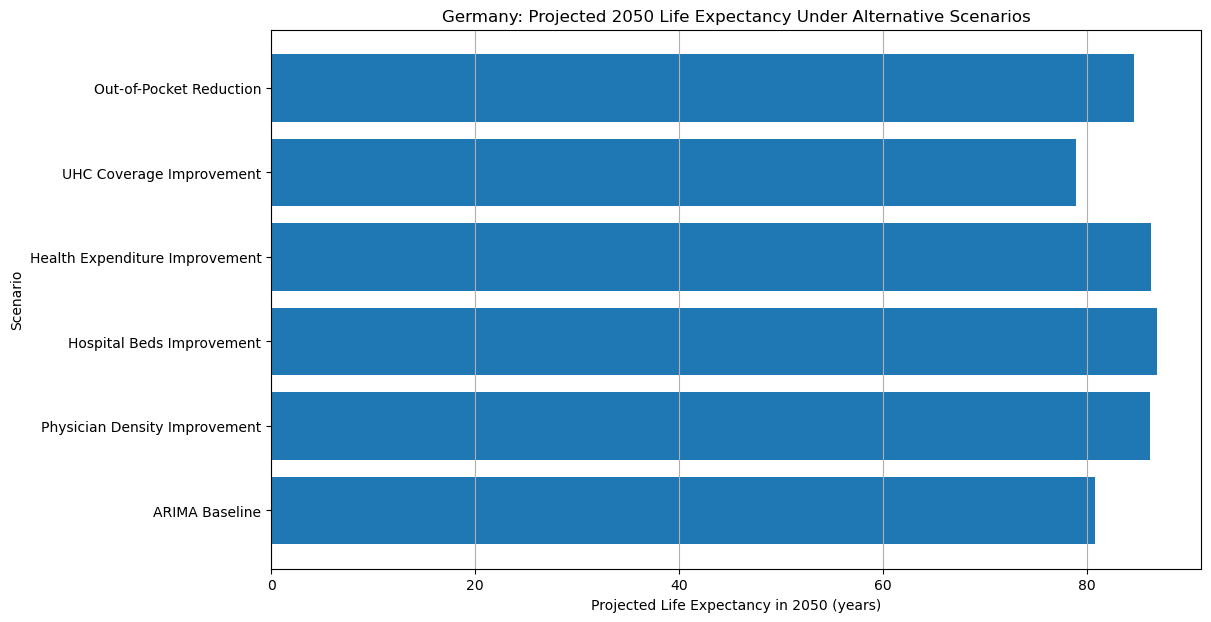

In [289]:
plt.figure(figsize=(12, 7))

plt.barh(
    germany_scenarios_2050["Scenario"],
    germany_scenarios_2050[
        "Life_Expectancy_2050"
    ]
)

plt.xlabel(
    "Projected Life Expectancy in 2050 (years)"
)

plt.ylabel("Scenario")

plt.title(
    "Germany: Projected 2050 Life Expectancy Under Alternative Scenarios"
)

plt.grid(axis="x")

plt.show()

In [290]:
print("INDIA COLUMNS")
print(india_forecast.columns.tolist())

INDIA COLUMNS
['Year', 'Life_Expectancy']


In [291]:
india_indicator_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

available_india = [
    col for col in india_indicator_columns
    if col in india_forecast.columns
]

missing_india = [
    col for col in india_indicator_columns
    if col not in india_forecast.columns
]

print("Available:")
print(available_india)

print("\nMissing:")
print(missing_india)

Available:
['Life_Expectancy']

Missing:
['Physician_Density', 'Hospital_Beds_Per_1000', 'Health_Expenditure_y', 'Out_of_Pocket', 'UHC_Coverage_Index']


In [292]:
# ============================================================
# INDIA — CORRECT HEALTHCARE INDICATOR DATASET
# ============================================================

india_indicators_clean = (
    india_indicators[
        [
            "Year",
            "Life_Expectancy",
            "Physician_Density",
            "Hospital_Beds_Per_1000",
            "Health_Expenditure_y",
            "Out_of_Pocket",
            "UHC_Coverage_Index"
        ]
    ]
    .dropna()
    .sort_values("Year")
    .reset_index(drop=True)
)

display(india_indicators_clean.head())
display(india_indicators_clean.tail())

print("Shape:", india_indicators_clean.shape)

,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket,UHC_Coverage_Index
0,1990,58.618,1.231000,0.769800,4.544816,91.589157,53.416667
1,1991,59.032,1.231000,0.787000,4.499428,90.265202,53.416667
2,1992,59.445,1.208565,0.936222,4.454041,88.941247,53.416667
3,1993,59.823,1.186130,1.085444,4.408654,87.617293,53.416667
4,1994,60.237,1.163696,1.234667,4.363266,86.293338,53.416667


,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket,UHC_Coverage_Index
30,2020,70.156,0.723,1.61,3.341461,49.510941,66.000000
31,2021,67.282,0.723,1.59,3.346809,45.109146,67.000000
32,2022,71.698,0.723,1.59,3.396235,44.541340,68.000000
33,2023,72.003,0.723,1.59,3.339440,43.885105,69.000000
34,2024,72.235,0.723,1.59,3.001649,46.574695,53.416667


Shape: (35, 7)


In [293]:
print("INDIA DATA AVAILABLE")
print()

for column in india_indicators_clean.columns:
    print(
        f"{column}: "
        f"{india_indicators_clean[column].notna().sum()} observations"
    )

INDIA DATA AVAILABLE

Year: 35 observations
Life_Expectancy: 35 observations
Physician_Density: 35 observations
Hospital_Beds_Per_1000: 35 observations
Health_Expenditure_y: 35 observations
Out_of_Pocket: 35 observations
UHC_Coverage_Index: 35 observations


In [294]:
# ============================================================
# INDIA — CORRELATION WITH LIFE EXPECTANCY
# EXCLUDING DIABETES AND NCD
# ============================================================

india_scenario_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

india_scenario_corr = (
    india_indicators_clean[
        india_scenario_columns
    ]
    .corr()["Life_Expectancy"]
    .sort_values(ascending=False)
)

print("🇮🇳 INDIA — CORRELATION WITH LIFE EXPECTANCY")
display(india_scenario_corr)

🇮🇳 INDIA — CORRELATION WITH LIFE EXPECTANCY


Life_Expectancy           1.000000
UHC_Coverage_Index        0.526648
Hospital_Beds_Per_1000    0.366750
Health_Expenditure_y     -0.924560
Out_of_Pocket            -0.939909
Physician_Density        -0.945292
Name: Life_Expectancy, dtype: float64

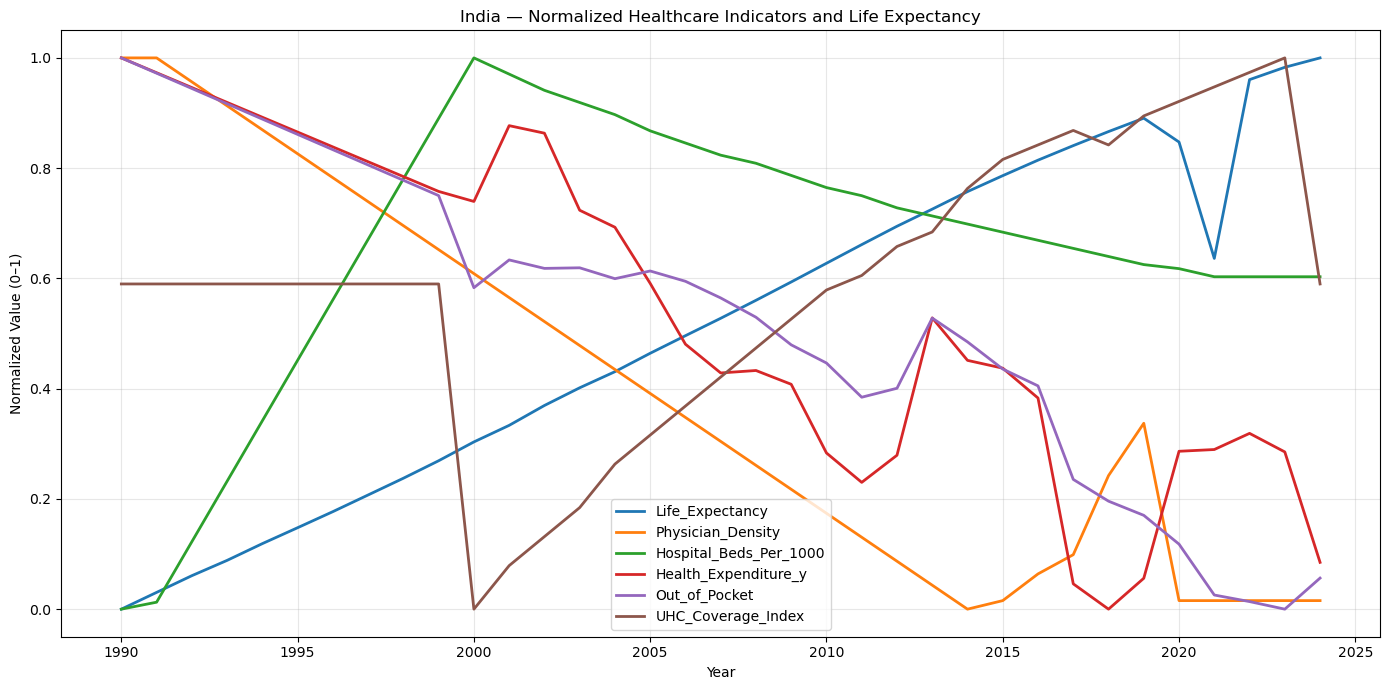

In [295]:
# ============================================================
# INDIA — HEALTH INDICATORS VS LIFE EXPECTANCY
# NORMALIZED TRAJECTORIES
# ============================================================

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

india_plot = india_indicators_clean.copy()

plot_columns = [
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

scaler = MinMaxScaler()

india_plot[plot_columns] = scaler.fit_transform(
    india_plot[plot_columns]
)

plt.figure(figsize=(14, 7))

for column in plot_columns:
    plt.plot(
        india_plot["Year"],
        india_plot[column],
        linewidth=2,
        label=column
    )

plt.title(
    "India — Normalized Healthcare Indicators and Life Expectancy"
)

plt.xlabel("Year")
plt.ylabel("Normalized Value (0–1)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [296]:
india_physician_improve, india_physician_model = create_indicator_scenario(
    india_indicators,
    india_2050_df,
    "Physician_Density",
    direction="improve",
    country="India"
)

display(india_physician_improve.head())
display(india_physician_improve.tail())

INDIA
Physician_Density
Scenario: improve
Historical annual change: -0.0149
Regression coefficient: -22.397
Regression R²: 0.8936

2050 result:


,Year,ARIMA_Baseline,Physician_Density,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,0.334529,78.675628,6.469328


,Year,ARIMA_Baseline,Physician_Density,Life_Expectancy_Scenario,Difference_vs_ARIMA
0,2025,72.202248,0.708059,70.309675,-1.892573
1,2026,72.206872,0.693118,70.644313,-1.562558
2,2027,72.206219,0.678176,70.978951,-1.227268
3,2028,72.206311,0.663235,71.313589,-0.892722
4,2029,72.206298,0.648294,71.648227,-0.558071


,Year,ARIMA_Baseline,Physician_Density,Life_Expectancy_Scenario,Difference_vs_ARIMA
21,2046,72.2063,0.394294,77.337075,5.130776
22,2047,72.2063,0.379353,77.671713,5.465414
23,2048,72.2063,0.364412,78.006352,5.800052
24,2049,72.2063,0.349471,78.340990,6.134690
25,2050,72.2063,0.334529,78.675628,6.469328


In [297]:
india_beds_improve, india_beds_model = create_indicator_scenario(
    india_indicators,
    india_2050_df,
    "Hospital_Beds_Per_1000",
    direction="improve",
    country="India"
)

print("🇮🇳 INDIA — HOSPITAL BEDS IMPROVEMENT")

display(
    india_beds_improve[
        india_beds_improve["Year"] == 2050
    ]
)

INDIA
Hospital_Beds_Per_1000
Scenario: improve
Historical annual change: 0.0241
Regression coefficient: 4.4356
Regression R²: 0.1345

2050 result:


,Year,ARIMA_Baseline,Hospital_Beds_Per_1000,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,2.217212,68.061905,-4.144395


🇮🇳 INDIA — HOSPITAL BEDS IMPROVEMENT


,Year,ARIMA_Baseline,Hospital_Beds_Per_1000,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,2.217212,68.061905,-4.144395


In [298]:
india_expenditure_improve, india_expenditure_model = create_indicator_scenario(
    india_indicators,
    india_2050_df,
    "Health_Expenditure_y",
    direction="improve",
    country="India"
)

print("🇮🇳 INDIA — HEALTH EXPENDITURE IMPROVEMENT")

display(
    india_expenditure_improve[
        india_expenditure_improve["Year"] == 2050
    ]
)

INDIA
Health_Expenditure_y
Scenario: improve
Historical annual change: -0.0454
Regression coefficient: -7.558
Regression R²: 0.8548

2050 result:


,Year,ARIMA_Baseline,Health_Expenditure_y,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,1.82158,80.336528,8.130228


🇮🇳 INDIA — HEALTH EXPENDITURE IMPROVEMENT


,Year,ARIMA_Baseline,Health_Expenditure_y,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,1.82158,80.336528,8.130228


In [299]:
india_uhc_improve, india_uhc_model = create_indicator_scenario(
    india_indicators,
    india_2050_df,
    "UHC_Coverage_Index",
    direction="improve",
    country="India"
)

print("🇮🇳 INDIA — UHC IMPROVEMENT")

display(
    india_uhc_improve[
        india_uhc_improve["Year"] == 2050
    ]
)

INDIA
UHC_Coverage_Index
Scenario: improve
Historical annual change: 0.0
Regression coefficient: 0.2251
Regression R²: 0.2774

2050 result:


,Year,ARIMA_Baseline,UHC_Coverage_Index,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,53.416667,65.585857,-6.620442


🇮🇳 INDIA — UHC IMPROVEMENT


,Year,ARIMA_Baseline,UHC_Coverage_Index,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,53.416667,65.585857,-6.620442


In [300]:
# ============================================================
# INDIA — REDUCTION IN OUT-OF-POCKET EXPENDITURE
# ============================================================

india_oop = (
    india_indicators[
        [
            "Year",
            "Life_Expectancy",
            "Out_of_Pocket"
        ]
    ]
    .dropna()
    .sort_values("Year")
    .reset_index(drop=True)
)

X = india_oop[["Out_of_Pocket"]]
y = india_oop["Life_Expectancy"]

india_oop_model = LinearRegression()

india_oop_model.fit(X, y)

first_value = india_oop["Out_of_Pocket"].iloc[0]
last_value = india_oop["Out_of_Pocket"].iloc[-1]

first_year = india_oop["Year"].iloc[0]
last_year = india_oop["Year"].iloc[-1]

annual_change = (
    last_value - first_value
) / (last_year - first_year)

future_years = np.arange(2025, 2051)

oop_improvement = (
    last_value
    - abs(annual_change)
    * (future_years - last_year)
)

india_oop_scenario = pd.DataFrame({
    "Year": future_years,
    "Out_of_Pocket": oop_improvement
})

india_oop_scenario[
    "Life_Expectancy_Scenario"
] = india_oop_model.predict(
    india_oop_scenario[
        ["Out_of_Pocket"]
    ]
)

india_oop_comparison = pd.merge(
    india_2050_df[
        ["Year", "Forecast"]
    ],
    india_oop_scenario,
    on="Year",
    how="inner"
)

india_oop_comparison = (
    india_oop_comparison
    .rename(
        columns={
            "Forecast": "ARIMA_Baseline"
        }
    )
)

india_oop_comparison[
    "Difference_vs_ARIMA"
] = (
    india_oop_comparison["Life_Expectancy_Scenario"]
    -
    india_oop_comparison["ARIMA_Baseline"]
)

print("🇮🇳 INDIA — OUT-OF-POCKET REDUCTION")

display(
    india_oop_comparison[
        india_oop_comparison["Year"] == 2050
    ]
)

🇮🇳 INDIA — OUT-OF-POCKET REDUCTION


,Year,ARIMA_Baseline,Out_of_Pocket,Life_Expectancy_Scenario,Difference_vs_ARIMA
25,2050,72.2063,12.151871,81.477452,9.271152


In [301]:
# ============================================================
# INDIA — FINAL 2050 SCENARIO COMPARISON
# ============================================================

india_scenarios_2050 = pd.DataFrame({

    "Scenario": [
        "ARIMA Baseline",
        "Physician Density Improvement",
        "Hospital Beds Improvement",
        "Health Expenditure Improvement",
        "UHC Coverage Improvement",
        "Out-of-Pocket Reduction"
    ],

    "Life_Expectancy_2050": [

        india_2050_df.loc[
            india_2050_df["Year"] == 2050,
            "Forecast"
        ].iloc[0],

        india_physician_improve.loc[
            india_physician_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        india_beds_improve.loc[
            india_beds_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        india_expenditure_improve.loc[
            india_expenditure_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        india_uhc_improve.loc[
            india_uhc_improve["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0],

        india_oop_comparison.loc[
            india_oop_comparison["Year"] == 2050,
            "Life_Expectancy_Scenario"
        ].iloc[0]
    ]
})

india_scenarios_2050[
    "Difference_from_ARIMA"
] = (
    india_scenarios_2050["Life_Expectancy_2050"]
    -
    india_scenarios_2050.loc[
        0,
        "Life_Expectancy_2050"
    ]
)

display(
    india_scenarios_2050.sort_values(
        "Life_Expectancy_2050",
        ascending=False
    )
)

,Scenario,Life_Expectancy_2050,Difference_from_ARIMA
5,Out-of-Pocket Reduction,81.477452,9.271152
3,Health Expenditure Improvement,80.336528,8.130228
1,Physician Density Improvement,78.675628,6.469328
0,ARIMA Baseline,72.206300,0.000000
2,Hospital Beds Improvement,68.061905,-4.144395
4,UHC Coverage Improvement,65.585857,-6.620442


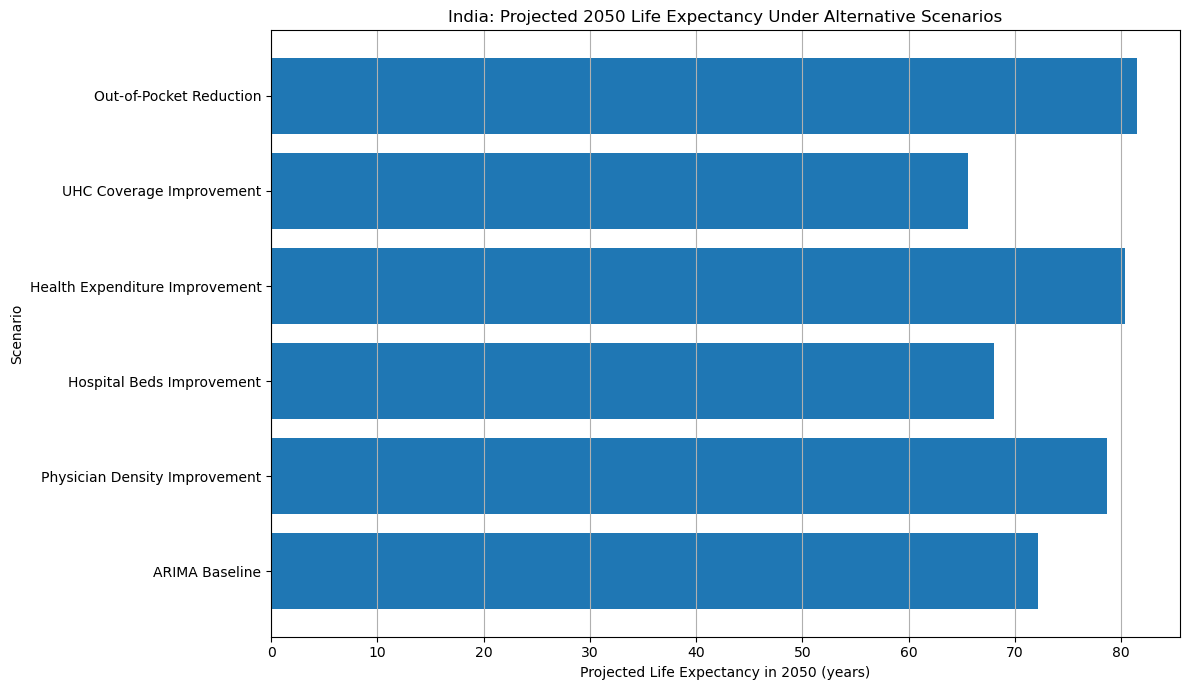

In [302]:
plt.figure(figsize=(12, 7))

plt.barh(
    india_scenarios_2050["Scenario"],
    india_scenarios_2050[
        "Life_Expectancy_2050"
    ]
)

plt.xlabel(
    "Projected Life Expectancy in 2050 (years)"
)

plt.ylabel("Scenario")

plt.title(
    "India: Projected 2050 Life Expectancy Under Alternative Scenarios"
)

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [303]:
germany_scenarios_2050.to_csv(
    "germany_scenarios_2050.csv",
    index=False
)

In [304]:
india_scenarios_2050.to_csv(
    "india_scenarios_2050.csv",
    index=False
)

In [305]:
print(type(germany_scenarios_2050))
print(germany_scenarios_2050.columns)

print(type(india_scenarios_2050))
print(india_scenarios_2050.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Scenario', 'Life_Expectancy_2050', 'Difference_from_ARIMA'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index(['Scenario', 'Life_Expectancy_2050', 'Difference_from_ARIMA'], dtype='object')


In [306]:
import os

print(os.getcwd())

C:\Users\Admin


In [601]:
# ============================================================
# EXPORT DATA FOR STREAMLIT APP
# ============================================================

indicator_columns = [
    "Year",
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket",
    "UHC_Coverage_Index"
]

germany_indicators[
    indicator_columns
].to_csv(
    "germany_indicators.csv",
    index=False
)

india_indicators[
    indicator_columns
].to_csv(
    "india_indicators.csv",
    index=False
)

print("Indicator files exported successfully.")

Indicator files exported successfully.
